# Create Survival Prediction Model using PyTorch

One strategy would be to replicate the [DeepSurv model](https://arxiv.org/abs/1606.00931), which is a deep neural network for survival analysis, essentially a nonlinear version of the Cox proportional hazard model. 

DeepSurv takes a list of features, and learns a risk function from input features. 
No restrictions, all types of data: clinical, gene expression, genetic mutations, are all treated the same. 

## Multi-modal Learning Model

Our data includes 3 unique modalities: 
- Clinical metadata
- Z-scored Gene Expression 
- Genetic Mutation data

So we will create separate encoders for each modality

Clinical features ──► Clinical MLP    ┐

Expression matrix ──► Expr Encoder ├─► Fusion ─► Risk score ─► Cox loss

Mutation matrix ────► Mut Encoder ─┘

## Architecture
1. Clinical Encoder (MLP): Low depth, minimal regularization
2. Gene Expression Encoder (Autoencoder or Bottleneck MLP)
Options: 
- Variance Filtered Genes
- Pathway Scores
- Autoencoder Latent Space
3. Mutational Autoencoder
- Binary gene-level mutation matrix
- Tumor mutational burden

## Training strategy 

1. Train clinical-only DeepSurv model
2. Add expression autoencoder (similar to Cox model) 
3. Add mutation autoencoder 
4. Fine-tune all layers

## Evaluation Strategies
Stratify patients by predicted risk tertiles

Plot Kaplan Meier curves

Compare against one another:

CoxPH (clinical)

CoxPH (clinical + expression)

DeepSurv multimodal

In [1]:
# load libraries
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import pyhere as here
from sklearn.preprocessing import StandardScaler


In [2]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### Load Data

In [3]:
### Load data 

# load clinical metadata
clinical = pd.read_csv(here.here("data", "processed","clinical_data.csv"))
# load expression data
expression_data = pd.read_csv(here.here("data", "processed","expression_data.csv"))
# mutation binary data
mutation_binary = pd.read_csv(here.here("data", "processed","mutation_binary_data.csv"))
# mutation classified data
mutation_classified = pd.read_csv(here.here("data", "processed","mutation_classified_data.csv"))

# Example of Multi-modal Learning Model

Mockup of what the final model will look like, with toy data

### Loss Function

In [4]:
# partial likelihood loss function for Cox Proportional Hazards model
def cox_ph_loss(risk_scores, times, events):
    """
    Negative partial log-likelihood for Cox PH
    """
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.sum((risk_scores - log_cumsum) * events)
    return loss / events.sum()

### Modality-specific Encoders

In [5]:
import torch.nn as nn

# clinical data encoder
class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
# Expression data encoder
class ExpressionEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
# Mutation data encoder
class MutationEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

### Multimodal DeepServ Model

In [8]:
# Multi-modal DeepSurv model, combining clinical, expression, and mutation data
class MultiModalDeepSurv(nn.Module):
    def __init__(self, clin_dim, expr_dim, mut_dim):
        super().__init__()

        self.clin_enc = ClinicalEncoder(clin_dim)
        self.expr_enc = ExpressionEncoder(expr_dim)
        self.mut_enc  = MutationEncoder(mut_dim)

        self.head = nn.Sequential(
            nn.Linear(32 + 128 + 64, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # regularization, prevents overfitting by setting 30% of neurons to zero during training
            nn.Linear(64, 1)
        )

    def forward(self, x_clin, x_expr, x_mut):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z_mut  = self.mut_enc(x_mut)

        z = torch.cat([z_clin, z_expr, z_mut], dim=1)
        return self.head(z).squeeze(-1)


# Training function for one epoch
def train_epoch(model, optimizer, x_clin, x_expr, x_mut, time, event):
    model.train()
    optimizer.zero_grad()

    risk = model(x_clin, x_expr, x_mut)
    loss = cox_ph_loss(risk, time, event)

    loss.backward()
    optimizer.step()
    return loss.item()


### Example run with randomized data

In [9]:
# example run with randomized data
N = 1500  # number of samples
C = 30      # clinical
G = 1000   # expression
M = 200    # mutation

x_clin = torch.randn(N, C)
x_expr = torch.randn(N, G)
x_mut  = torch.randint(0, 2, (N, M)).float()

time  = torch.rand(N) * 100
event = torch.randint(0, 2, (N,)).float()

model = MultiModalDeepSurv(C, G, M)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    loss = train_epoch(
        model,
        optimizer,
        x_clin,
        x_expr,
        x_mut,
        time,
        event
    )
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")


Epoch 0 | Loss: 6.3553
Epoch 10 | Loss: 5.8081
Epoch 20 | Loss: 4.6652
Epoch 30 | Loss: 4.6254
Epoch 40 | Loss: 4.4363


### Evaluation (C-index)

In [10]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk = model(x_clin, x_expr, x_mut).numpy()

c_index = concordance_index(
    time.numpy(),
    -risk,
    event.numpy()
)

print("C-index:", c_index)


C-index: 0.9801472748958532


Remarkably good C-index! (Almost like the data isn't real! )

Next, we will train the model in increments, beginning with the clinical encoder only.

# Clinical-only Model

To begin, we will train a neural Cox model using only clinical variables, similar to the original Cox Hazard model. 

Once we have an effective model using only clinical features, we can expand it to clinical + gene expression, and finally, clinical, gene expression, and mutation data. 

## Clinical DeepSurv model class
This is a single neural network with a sequence of:
- Linear layer (input -> 32 dim)
- ReLu
- 20% dropout normalization
- Final linear layer (32 dim -> risk score)

### First: Encode clinical data for use with PyTorch

Clinical data includes categorical/ string based data, while PyTorch expects data as tensors. 

We will one-hot encode categorical data. 

In [11]:
import pandas as pd
pd.set_option('display.max_columns', None)

# overview of our clinical data
clinical.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [12]:
# define outcome variables
df = clinical.copy()
time_col = "overall_survival_months"
event_col = "death_from_cancer"

# 'event' will be 1 if died of cancer of disease, 0 otherwise (including died of other causes or alive)
df["event"] = (df[event_col] == "Died of Disease").astype(int)
df["time"] = df[time_col]


In [13]:
df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,event,time
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,0,140.500000
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,0,84.633333
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,1,163.700000
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,0,164.933333
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1,41.366667


In [14]:
df[["3-gene_classifier_subtype"]].value_counts()

3-gene_classifier_subtype
ER+/HER2- Low Prolif         619
ER+/HER2- High Prolif        603
ER-/HER2-                    290
unknown                      204
HER2+                        188
Name: count, dtype: int64

In [15]:
# group rare cancer types into "Other" category
# This will make one hot encoding and modeling more robust by reducing the number of categories with very few samples
rare_threshold = 50

value_counts = df["cancer_type_detailed"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["cancer_type_detailed_clean"] = df["cancer_type_detailed"].replace(
    rare_classes, "Other"
)

# do same for histologic subtype
value_counts = df["tumor_other_histologic_subtype"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["tumor_other_histologic_subtype_clean"] = df["tumor_other_histologic_subtype"].replace(
    rare_classes, "Other"
)

In [16]:
df[["cancer_type_detailed","cancer_type_detailed_clean"]].value_counts()

cancer_type_detailed                       cancer_type_detailed_clean               
Breast Invasive Ductal Carcinoma           Breast Invasive Ductal Carcinoma             1500
Breast Mixed Ductal and Lobular Carcinoma  Breast Mixed Ductal and Lobular Carcinoma     207
Breast Invasive Lobular Carcinoma          Breast Invasive Lobular Carcinoma             142
Breast Invasive Mixed Mucinous Carcinoma   Other                                          22
Breast                                     Other                                          17
Metaplastic Breast Cancer                  Other                                           1
Name: count, dtype: int64

In [17]:
df[["tumor_other_histologic_subtype","tumor_other_histologic_subtype_clean"]].value_counts()

tumor_other_histologic_subtype  tumor_other_histologic_subtype_clean
Ductal/NST                      Ductal/NST                              1454
Mixed                           Mixed                                    207
Lobular                         Lobular                                  142
Medullary                       Other                                     25
Mucinous                        Other                                     22
Tubular/ cribriform             Other                                     21
Other                           Other                                     17
Metaplastic                     Other                                      1
Name: count, dtype: int64

In [18]:
df

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,event,time,cancer_type_detailed_clean,tumor_other_histologic_subtype_clean
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,0,140.500000,Breast Invasive Ductal Carcinoma,Ductal/NST
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,0,84.633333,Breast Invasive Ductal Carcinoma,Ductal/NST
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,1,163.700000,Breast Invasive Ductal Carcinoma,Ductal/NST
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,0,164.933333,Breast Mixed Ductal and Lobular Carcinoma,Mixed
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1,41.366667,Breast Mixed Ductal and Lobular Carcinoma,Mixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Lobular,1,Pre,3,Right,1.0,4.0,5.050,ILC,196.866667,1,Positive,1,ER+/HER2- Low Prolif,25.0,unknown,Living,0,196.866667,Breast Invasive Lobular Carcinoma,Lobular
1900,7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,GAIN,Positive,Ductal/NST,0,Pre,5,NaN,1.0,6.0,5.040,IDC,44.733333,0,Negative,1,unknown,20.0,unknown,Died of Disease,1,44.733333,Breast Invasive Ductal Carcinoma,Ductal/NST
1901,7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,Left,45.0,4.0,6.050,IDC,175.966667,0,Positive,1,unknown,25.0,unknown,Died of Disease,1,175.966667,Breast Invasive Ductal Carcinoma,Ductal/NST
1902,7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,NaN,12.0,15.0,5.050,IDC,86.233333,0,Positive,0,ER+/HER2- High Prolif,25.0,unknown,Died of Other Causes,0,86.233333,Breast Invasive Ductal Carcinoma,Ductal/NST


In [19]:
# Drop identifiers, outcome columns, and pre-modified columns from clinical features
drop_cols = [
    # original columns to drop
    "patient_id",
    "cancer_type",
    "cohort",
    "cancer_type_detailed",
    "er_status_measured_by_ihc",
    "her2_status_measured_by_snp6",
    "tumor_other_histologic_subtype",
    "integrative_cluster",
    "oncotree_code",
    "radio_therapy",
    "chemotherapy",
    "type_of_breast_surgery",
    "hormone_therapy", 
    "overall_survival",
    # updated drop columns 
    "nottingham_prognostic_index",  # composite of existing features
    "3-gene_classifier_subtype",    # derived from ER/PR/HER2
    "tumor_other_histologic_subtype_clean",  # redundant with cancer_type_detailed
    
    time_col,
    event_col
]

# X will now contain only clinical features that will go into model training
X = df.drop(columns=drop_cols + ["event", "time"])
y_time = df["time"].values
y_event = df["event"].values

#### Identify feature types

In [20]:
# different data types in clinical data
X.dtypes.value_counts()

object     9
float64    5
Name: count, dtype: int64

In [21]:
# identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# fill missing categorical data with "Unknown"
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

In [22]:
numeric_cols

['age_at_diagnosis',
 'neoplasm_histologic_grade',
 'lymph_nodes_examined_positive',
 'mutation_count',
 'tumor_size']

In [23]:
categorical_cols

['cellularity',
 'pam50_+_claudin-low_subtype',
 'er_status',
 'her2_status',
 'inferred_menopausal_state',
 'primary_tumor_laterality',
 'pr_status',
 'tumor_stage',
 'cancer_type_detailed_clean']

#### Train/Validation Split 

In [24]:
from sklearn.model_selection import train_test_split

# First split off test set (hold this out entirely until the end)
X_temp, X_test, time_temp, time_test, event_temp, event_test = train_test_split(
    X, y_time, y_event,
    test_size=0.15,
    stratify=y_event,
    random_state=42
)

# Then split remaining into train/val
X_train, X_val, time_train, time_val, event_train, event_val = train_test_split(
    X_temp, time_temp, event_temp,
    test_size=0.2,
    stratify=event_temp,
    random_state=42
)

#### Process numeric features for training and validation set separately
Scaling/imputation depends on the data that we see, so we must normalize the data separately for training and validation to prevent data leakage

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train[numeric_cols])
X_train_num = scaler.fit_transform(X_train_num)

X_val_num = num_imputer.transform(X_val[numeric_cols])
X_val_num = scaler.transform(X_val_num)

X_test_num = num_imputer.transform(X_test[numeric_cols])
X_test_num = scaler.transform(X_test_num)

#### Process categorical features separately 
One-hot encode separately

In [26]:
X_train_cat = pd.get_dummies(
    X_train[categorical_cols],
    drop_first=True
).astype(float)

X_val_cat = pd.get_dummies(
    X_val[categorical_cols],
    drop_first=True
).astype(float)

X_val_cat = X_val_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

X_test_cat = pd.get_dummies(
    X_test[categorical_cols],
    drop_first=True
).astype(float)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

#### Combine features

In [27]:
import numpy as np

X_train_final = np.hstack([
    X_train_num.astype(np.float32),
    X_train_cat.values.astype(np.float32)
])

X_val_final = np.hstack([
    X_val_num.astype(np.float32),
    X_val_cat.values.astype(np.float32)
])

X_test_final = np.hstack([
    X_test_num.astype(np.float32),
    X_test_cat.values.astype(np.float32)
])

In [28]:
X_val_final.dtype

dtype('float32')

In [29]:
X_train_final.shape

(1294, 29)

#### Convert to PyTorch Tensors

In [30]:
import torch

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
time_train_tensor = torch.tensor(time_train, dtype=torch.float32)
event_train_tensor = torch.tensor(event_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_final, dtype=torch.float32)
time_val_tensor = torch.tensor(time_val, dtype=torch.float32)
event_val_tensor = torch.tensor(event_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)
time_test_tensor = torch.tensor(time_test, dtype=torch.float32)
event_test_tensor = torch.tensor(event_test, dtype=torch.float32)


In [31]:
print(X_val_num.dtype)
print(X_val_cat.dtypes.value_counts())


float64
float64    23
int64       1
Name: count, dtype: int64


#### Clinical Only DeepSurv model class definition

In [32]:
import torch.nn as nn

class ClinicalSurvNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),  # 14 → 32
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),         # 32 → 16
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)           # 16 → risk score
        )

    def forward(self, x):
        return self.net(x).squeeze()

#### Cox partial likelihood loss

In [33]:
def cox_loss(risk, time, event):
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    log_cumsum = torch.logcumsumexp(risk, dim=0)
    loss = -torch.sum((risk - log_cumsum) * event) / event.sum()
    return loss


#### Model training

In [34]:
from lifelines.utils import concordance_index
import torch

def compute_cindex(model, X_tensor, time_array, event_array):
    """
    Compute the concordance index for a PyTorch model.
    
    Parameters:
        model : torch.nn.Module
            Trained survival model that outputs risk scores
        X_tensor : torch.Tensor
            Input features
        time_array : np.array
            Survival times
        event_array : np.array
            Event indicator (1=event, 0=censored)
            
    Returns:
        c_index : float
            Concordance index
    """
    model.eval()
    with torch.no_grad():
        risk_scores = model(X_tensor).numpy()
    
    return concordance_index(time_array, -risk_scores, event_array)

In [35]:
model = ClinicalSurvNet(X_train_final.shape[1])
# Adam optimizer with weight decay for L2 regularization to prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler that reduces LR by half if validation C-index doesn't improve for 20 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

best_val_cindex = 0
patience = 50
epochs_no_improve = 0
best_weights = None

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()

    risk = model(X_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)

    loss.backward()
    optimizer.step()

    # Check validation every 10 epochs, record best validation C-index and implement early stopping
    if epoch % 10 == 0:
        val_cindex = compute_cindex(model, X_val_tensor, time_val, event_val)

        if val_cindex > best_val_cindex:
            best_val_cindex = val_cindex
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Update learning rate based on validation C-index
    scheduler.step(val_cindex)
    
# Restore best weights
model.load_state_dict(best_weights)
print(f"Best validation C-index: {best_val_cindex:.4f}")

Epoch 0, Loss: 6.6596
Epoch 25, Loss: 6.6188
Epoch 50, Loss: 6.5227
Epoch 75, Loss: 6.4539
Epoch 100, Loss: 6.4345
Epoch 125, Loss: 6.4148
Epoch 150, Loss: 6.3972
Epoch 175, Loss: 6.4270
Epoch 200, Loss: 6.3866
Epoch 225, Loss: 6.3989
Epoch 250, Loss: 6.4192
Epoch 275, Loss: 6.4272
Epoch 300, Loss: 6.4007
Epoch 325, Loss: 6.4061
Epoch 350, Loss: 6.3929
Epoch 375, Loss: 6.4104
Epoch 400, Loss: 6.4151
Epoch 425, Loss: 6.4298
Epoch 450, Loss: 6.4173
Epoch 475, Loss: 6.4106
Epoch 500, Loss: 6.4233
Epoch 525, Loss: 6.4220
Epoch 550, Loss: 6.4044
Epoch 575, Loss: 6.3975
Early stopping at epoch 580
Best validation C-index: 0.7421


## Model Evaluation
#### Evaluate on validation set

In [36]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

c_index = concordance_index(
    time_val,
    -val_risk,
    event_val
)

print("Validation C-index:", c_index)


Validation C-index: 0.7420578670891353


# Clinical-only Evaluation
#### Compare training and validation C-index

### Concordance Index (C-index)

The C-index measures how well the model **ranks** patients by risk — 
specifically, whether patients who die sooner have higher predicted risk scores.

#### Concordant Pairs

For every pair of patients $(i, j)$ where patient $i$ died before patient $j$
(i.e. $T_i < T_j$ and $\delta_i = 1$), we ask: did the model correctly assign
a higher risk score to patient $i$?

A pair is called **concordant** if:

$$
\hat{r}_i > \hat{r}_j \quad \text{when} \quad T_i < T_j
$$

Where $\hat{r}_i$ is the predicted risk score for patient $i$.

#### Formula

$$
C = \frac{\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \mathbf{1}(\hat{r}_i > \hat{r}_j) \cdot \delta_i}
         {\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \delta_i}
$$

Where:
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{r}_i$ = predicted risk score for patient $i$
- The sums run over all **comparable pairs** — pairs where the shorter 
survival time is an observed event (not censored)

#### Handling Censoring

Pairs where the earlier time is censored are **excluded** from both the 
numerator and denominator, because we cannot confirm who truly died first.
This is enforced by the $\delta_i = 1$ term.

#### Interpretation

| C-index | Interpretation |
|---------|---------------|
| $1.0$ | Perfect ranking — model always ranks higher-risk patients correctly |
| $0.5$ | Random chance — no better than flipping a coin |
| $< 0.5$ | Worse than random (inverted predictions) |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

#### Relationship to AUC

The C-index is equivalent to the **Area Under the ROC Curve (AUC)** 
for binary outcomes. For survival data it generalizes AUC to handle 
censoring and continuous time, which is why it is sometimes called the 
**concordance statistic** or **Harrell's C**.

> **Note:** The C-index measures *ranking ability* only — not whether 
> predicted probabilities are accurate. A model can have a high C-index 
> but poor calibration. This is why it should be reported alongside the 
> Integrated Brier Score.

In [37]:
# Example usage after training
train_cindex = compute_cindex(model, X_train_tensor, time_train, event_train)
val_cindex   = compute_cindex(model, X_val_tensor, time_val, event_val)
test_cindex  = compute_cindex(model, X_test_tensor, time_test, event_test)

print(f"Training C-index: {train_cindex:.4f}")
print(f"Validation C-index: {val_cindex:.4f}")
print(f"Test C-index: {test_cindex:.4f}")

Training C-index: 0.7255
Validation C-index: 0.7421
Test C-index: 0.7208


In [38]:
import numpy as np

# helper function to convert event/time arrays to structured array format for sksurv compatibility
def make_structured_array(event, time):
    """Convert event/time arrays to sksurv structured array format"""
    return np.array(
        [(bool(e), t) for e, t in zip(event, time)],
        dtype=[('event', bool), ('time', float)]
    )

In [39]:
# Recompute structured arrays and risk scores
surv_train = make_structured_array(event_train, time_train)
surv_val   = make_structured_array(event_val, time_val)

model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()
    val_risk   = model(X_val_tensor).numpy()

### Kaplan-Meier Curves by Predicted Risk Tertile

Kaplan-Meier (KM) curves provide a visual, clinically interpretable evaluation
of the model by showing whether patients assigned to different risk groups have
genuinely different survival trajectories.

#### Risk Stratification

Patients are divided into three groups based on their predicted risk score $\hat{r}_i$:

$$
\text{Group} = \begin{cases}
\text{Low Risk}  & \hat{r}_i < Q_{33} \\
\text{Mid Risk}  & Q_{33} \leq \hat{r}_i < Q_{66} \\
\text{High Risk} & \hat{r}_i \geq Q_{66}
\end{cases}
$$

Where $Q_{33}$ and $Q_{66}$ are the 33rd and 66th percentiles of the predicted
risk scores.

#### The Kaplan-Meier Estimator

Within each risk group, the survival function $\hat{S}(t)$ — the probability 
of surviving past time $t$ — is estimated using the Kaplan-Meier product-limit 
estimator:

$$
\hat{S}(t) = \prod_{j:\, t_j \leq t} \left(1 - \frac{d_j}{n_j}\right)
$$

Where:
- $t_j$ = each time point where at least one death occurs
- $d_j$ = number of deaths at time $t_j$
- $n_j$ = number of patients still at risk just before time $t_j$
- The product runs over all event times up to and including $t$

#### Handling Censoring

Censored patients (those lost to follow-up or still alive at study end) 
do not contribute a death to $d_j$, but they **do** count toward $n_j$ 
up until their censoring time. After that point they are removed from 
the at-risk set. This is why KM curves can be estimated even when not 
all patients have experienced the event.

#### What Good Separation Looks Like

A well-performing model should produce **clearly separated curves**:

- The **high risk** group drops steeply — many early deaths
- The **low risk** group remains high — patients survive longer
- The **mid risk** group falls between the two

Curves that overlap or cross suggest the model's risk scores are not 
meaningfully stratifying patients.

#### Statistical Significance

Separation between curves is formally tested with the **multivariate 
log-rank test**, which tests the null hypothesis:

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

A p-value $< 0.05$ indicates the survival curves are statistically 
significantly different across groups.

#### Interpretation

| Observation | Meaning |
|-------------|---------|
| Wide separation between curves | Model discriminates risk well |
| Log-rank $p < 0.05$ | Separation is statistically significant |
| Curves crossing | Proportional hazards assumption may be violated |
| High and low risk curves overlap | Model has poor stratification ability |

> **Note:** KM curves show *observed* survival in each predicted risk group.
> Unlike the C-index, they are easily interpretable by a clinical audience
> and directly answer the question: *"Do my predicted risk groups correspond 
> to meaningfully different patient outcomes?"*

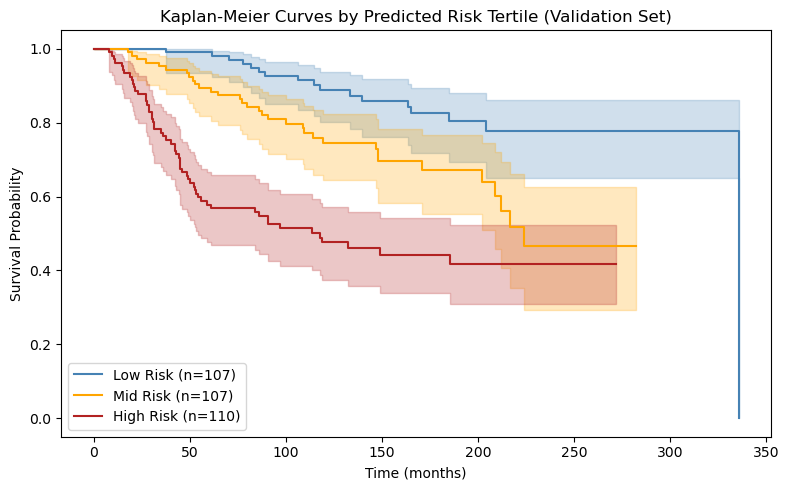

In [40]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

# Split into risk tertiles
tertiles = np.percentile(val_risk, [33, 66])
risk_group = np.digitize(val_risk, tertiles)  # 0=low, 1=mid, 2=high

# KM curves
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for group, label, color in zip(
    [0, 1, 2],
    ["Low Risk", "Mid Risk", "High Risk"],
    ["steelblue", "orange", "firebrick"]
):
    mask = risk_group == group
    kmf.fit(time_val[mask], event_val[mask], label=f"{label} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier Curves by Predicted Risk Tertile (Validation Set)")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

### Multivariate Log-Rank Test

The log-rank test formally tests whether the survival curves across predicted
risk groups are **statistically distinguishable** from one another, or whether
the observed differences could be due to random chance.

#### Null Hypothesis

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

Under $H_0$, group membership has no effect on survival — deaths are distributed
proportionally to group size at every time point.

#### Setup

Let there be $K$ groups and $M$ distinct event times $t_1 < t_2 < \cdots < t_M$.

At each event time $t_j$, define:

- $d_{jk}$ = observed deaths in group $k$ at time $t_j$
- $n_{jk}$ = patients at risk in group $k$ just before $t_j$
- $d_j = \sum_k d_{jk}$ = total deaths at $t_j$
- $n_j = \sum_k n_{jk}$ = total patients at risk at $t_j$

#### Expected Deaths

Under $H_0$, the expected number of deaths in group $k$ at time $t_j$ is:

$$
e_{jk} = n_{jk} \times \frac{d_j}{n_j}
$$

That is, each group's share of the at-risk pool, multiplied by the total
number of deaths at that time point.

#### Observed Minus Expected

For each group $k$, accumulate the difference between observed and expected
deaths across all event times:

$$
U_k = \sum_{j=1}^{M} (d_{jk} - e_{jk})
$$

Collected into a vector of length $K-1$ (the last group is determined by the others
since $\sum_k U_k = 0$):

$$
\mathbf{U} = [U_1, U_2, \ldots, U_{K-1}]^\top
$$

#### Variance-Covariance Matrix

The variance of $U_k$ and covariance between groups $k$ and $l$ at each event
time come from the hypergeometric distribution. Summing across all event times:

$$
V_{kk} = \sum_{j=1}^{M} \frac{n_{jk}(n_j - n_{jk}) \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
$$

$$
V_{kl} = -\sum_{j=1}^{M} \frac{n_{jk} \cdot n_{jl} \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
\quad k \neq l
$$

This gives the full $(K-1) \times (K-1)$ variance-covariance matrix $\mathbf{V}$.

#### Test Statistic

The test statistic is the quadratic form:

$$
\chi^2 = \mathbf{U}^\top \mathbf{V}^{-1} \mathbf{U}
$$

Under $H_0$, this follows a **chi-squared distribution** with $K-1$ degrees
of freedom. For three risk groups ($K=3$), this gives $df = 2$.

#### P-value

$$
p = P(\chi^2_{K-1} \geq \chi^2_{\text{observed}})
$$

A small p-value indicates the observed survival differences are unlikely
under $H_0$, and we reject the hypothesis that all groups have equal survival.

#### Interpretation

| Result | Meaning |
|--------|---------|
| $p < 0.05$ | Survival curves are significantly different across groups |
| $p \geq 0.05$ | No significant difference detected |
| Large $\chi^2$, small $p$ | Strong evidence of risk stratification |
| $U_k \gg 0$ for low risk | Fewer deaths than expected — model correctly identified survivors |
| $U_k \ll 0$ for high risk | More deaths than expected — model correctly identified high risk patients |

#### Assumptions

- **Proportional hazards:** the relative difference between groups is consistent
  over time. If KM curves cross, this assumption is violated and the log-rank
  test loses statistical power
- **Independent censoring:** censoring is unrelated to the probability of the event
- **Large sample:** the $\chi^2$ approximation holds when event counts are not too small

> **Note:** The log-rank test confirms *statistical significance* of group separation
> but not *effect size*. A significant p-value with overlapping KM curves (common in
> large samples) may not be clinically meaningful. Always interpret alongside the
> KM plot and hazard ratios.

In [41]:
# Log-rank test
logrank = multivariate_logrank_test(time_val, risk_group, event_val)
print(f"Log-rank p-value: {logrank.p_value:.4f}")
logrank.print_summary()

Log-rank p-value: 0.0000


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          48.60 <0.005     35.06

### Integrated Brier Score

#### Brier Score measures calibration: 
##### If the model predicts a patient has a 70% chance of surviving for 5 years, are ~70% of patients alive after 5 years? 

Brier Score evaluates the accuracy of the predicted survival function at a given time t. 

Represents average squared distances between observed survival status and predicted survival probability, and is always between 0 and 1 (0 is best possible value).

## Integrated Brier Score

The Brier Score at a single time point $t$ is:

$$
BS(t) = \frac{1}{n} \sum_{i=1}^{n} \left[
    \frac{\mathbf{1}(T_i \leq t,\, \delta_i = 1)}{\hat{G}(T_i)} \cdot \hat{S}_i(t)^2
    + \frac{\mathbf{1}(T_i > t)}{\hat{G}(t)} \cdot (1 - \hat{S}_i(t))^2
\right]
$$

Where:
- $\hat{S}_i(t)$ = predicted survival probability for patient $i$ at time $t$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{G}(t)$ = Kaplan-Meier estimate of the censoring distribution (IPCW weight)

The **Integrated Brier Score** averages $BS(t)$ over a time range $[t_{min}, t_{max}]$:

$$
\text{IBS} = \frac{1}{t_{max} - t_{min}} \int_{t_{min}}^{t_{max}} BS(t)\, dt
$$

In our case, we stop evaluation after the 90th percentile because survival estimates become unreliable in the tail where few patients remain at risk

| IBS | Interpretation |
|-----|---------------|
| $< 0.15$ | Good calibration |
| $0.25$ | Uninformative (null model) |
| $> 0.25$ | Worse than no predictors |

In [42]:
def compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val):
    """
    Compute the Integrated Brier Score for a survival model.

    Parameters:
        train_risk  : np.array — risk scores for training set
        val_risk    : np.array — risk scores for validation/test set
        surv_train  : structured array — training survival data (event, time)
        surv_val    : structured array — validation survival data (event, time)
        time_val    : np.array — survival times for validation/test set

    Returns:
        ibs : float — Integrated Brier Score
    """
    from sksurv.metrics import integrated_brier_score
    from sksurv.linear_model import CoxPHSurvivalAnalysis

    # Fit Cox reference on training risk scores to get baseline hazard
    cox_ref = CoxPHSurvivalAnalysis()
    cox_ref.fit(train_risk.reshape(-1, 1), surv_train)

    # Time grid within observed range
    times_ibs = np.linspace(
        time_val.min() + 1,
        np.percentile(time_val, 90),
        100
    )

    # Get survival probabilities for each patient at each time point
    surv_fns = cox_ref.predict_survival_function(val_risk.reshape(-1, 1))
    surv_probs = np.vstack([fn(times_ibs) for fn in surv_fns])

    ibs = integrated_brier_score(surv_train, surv_val, surv_probs, times_ibs)
    return ibs

In [43]:
ibs = compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val)
print(f"Integrated Brier Score: {ibs:.4f}")

Integrated Brier Score: 0.1451


### Time-Dependent AUC

The standard C-index summarizes discrimination across all time points in a
single number. Time-dependent AUC extends this by asking: **how well does
the model discriminate survival at each specific time point?** This is
particularly useful for identifying whether the model performs better at
predicting short-term versus long-term survival.

#### Defining Cases and Controls at Time $t$

At each time point $t$, patients are classified as:

- **Case:** patient $i$ experienced the event before $t$, i.e. $T_i \leq t$ and $\delta_i = 1$
- **Control:** patient $j$ survived past $t$, i.e. $T_j > t$

This classification changes at every time point — a patient who is a control
at $t = 12$ months may become a case at $t = 36$ months.

#### AUC at a Single Time Point

For a given time $t$, the AUC measures the probability that a randomly
selected case has a higher predicted risk score than a randomly selected
control:

$$
\text{AUC}(t) = P\left(\hat{r}_i > \hat{r}_j \mid T_i \leq t,\, \delta_i = 1,\, T_j > t\right)
$$

Where:
- $\hat{r}_i$ = predicted risk score for patient $i$
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)

This is equivalent to the area under the ROC curve at time $t$, where the
ROC curve is constructed by varying the risk score threshold and plotting:

$$
\text{Sensitivity}(t) = P(\hat{r}_i > c \mid T_i \leq t,\,\delta_i = 1)
$$

$$
1 - \text{Specificity}(t) = P(\hat{r}_j > c \mid T_j > t)
$$

#### Handling Censoring with IPCW

Censored patients create ambiguity — a patient censored at $t = 24$ months
cannot be classified as a case or control at $t = 36$ months. This is
resolved using **Inverse Probability of Censoring Weighting (IPCW)**,
which reweights the contribution of each patient by the inverse probability
of not being censored:

$$
\text{AUC}(t) = \frac{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{\mathbf{1}(\hat{r}_i > \hat{r}_j)}{\hat{G}(T_i)\,\hat{G}(t)}
}{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{1}{\hat{G}(T_i)\,\hat{G}(t)}
}
$$

Where $\hat{G}(t)$ is the Kaplan-Meier estimate of the censoring distribution.
Patients who were likely to be censored receive higher weights, compensating
for their underrepresentation in the observed data.

#### Cumulative vs. Incident AUC

There are two common definitions of cases and controls:

$$
\text{Cumulative/Dynamic AUC: cases are } \{i : T_i \leq t,\, \delta_i = 1\}
$$

$$
\text{Incident/Dynamic AUC: cases are } \{i : T_i = t,\, \delta_i = 1\}
$$

**Cumulative AUC** (used by `sksurv`) accumulates all deaths up to $t$ as
cases — this is more stable because it uses more events per time point,
especially useful when events are rare at any single time.

#### Mean AUC

To summarize discrimination across all evaluated time points
$t_1, t_2, \ldots, t_M$, the mean AUC weights each time point by the
proportion of total events occurring up to that time:

$$
\overline{\text{AUC}} = \frac{1}{\hat{S}(t_{\min}) - \hat{S}(t_{\max})}
\int_{t_{\min}}^{t_{\max}} \text{AUC}(t)\, d\hat{F}(t)
$$

Where $\hat{F}(t) = 1 - \hat{S}(t)$ is the estimated marginal event
probability. In practice this integral is approximated over the discrete
set of evaluation time points.

#### Evaluated Time Points

In your model, AUC is evaluated at clinically meaningful time points:

| Time Point | Clinical Relevance |
|------------|--------------------|
| $t = 12$ months | 1-year survival |
| $t = 36$ months | 3-year survival |
| $t = 60$ months | 5-year survival |
| $t = 84$ months | 7-year survival |

#### Interpretation

| AUC$(t)$ | Meaning |
|----------|---------|
| $1.0$ | Perfect discrimination at time $t$ |
| $0.5$ | Random chance — no better than a coin flip |
| $< 0.5$ | Inverted predictions |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

A **declining AUC over time** is expected and normal — short-term risk
is generally easier to predict than long-term risk, as the influence of
measured clinical features weakens over longer follow-up periods.

#### Relationship to C-index

The C-index can be seen as a weighted average of $\text{AUC}(t)$ across
all event times, whereas time-dependent AUC resolves *when* discrimination
is strongest. A model with a moderate C-index may still have high AUC at
clinically critical time points such as 1-year or 5-year survival.

> **Note:** Time-dependent AUC measures *discrimination* — whether the model
> correctly ranks cases above controls at each time point. Like the C-index,
> it does not measure calibration. Always report alongside the Integrated
> Brier Score for a complete picture of model performance.


Time-dependent AUC:
  1-year AUC (12mo): 0.9486
  3-year AUC (36mo): 0.8476
  5-year AUC (60mo): 0.8460
  7-year AUC (84mo): 0.7935
  Mean AUC: 0.8441


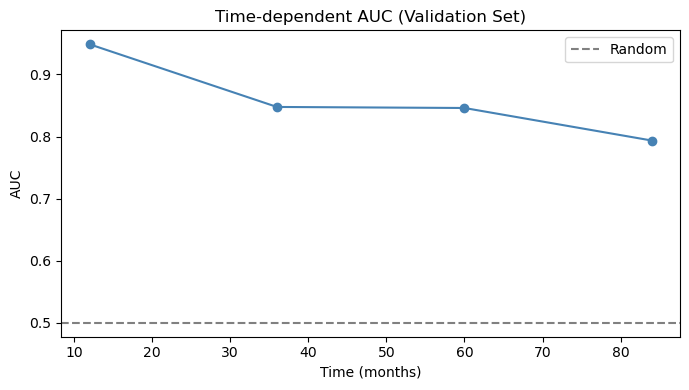

In [44]:
from sksurv.metrics import cumulative_dynamic_auc

# Clinically meaningful time points for breast cancer (months)
eval_times = [12, 36, 60, 84]  # 1, 3, 5, 7 years

# Filter to times within observed range
max_time = np.percentile(time_val, 90)
eval_times = [t for t in eval_times if t < max_time]

auc_scores, mean_auc = cumulative_dynamic_auc(
    surv_train, surv_val,
    val_risk,  # negative because higher risk = lower survival
    eval_times
)

print(f"\nTime-dependent AUC:")
for t, auc in zip(eval_times, auc_scores):
    years = t // 12
    print(f"  {years}-year AUC ({t}mo): {auc:.4f}")
print(f"  Mean AUC: {mean_auc:.4f}")

# Plot AUC over time
plt.figure(figsize=(7, 4))
plt.plot(eval_times, auc_scores, marker='o', color='steelblue')
plt.axhline(0.5, linestyle='--', color='gray', label='Random')
plt.xlabel("Time (months)")
plt.ylabel("AUC")
plt.title("Time-dependent AUC (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation Metrics Wrapped Together

In [45]:
def evaluate_model(model, X_tensor, time_arr, event_arr, surv_train,
                   train_risk=None, label="Validation"):
    """
    Evaluate a survival model with C-index, time-dependent AUC, and IBS.

    Parameters:
        model       : torch.nn.Module — trained survival model
        X_tensor    : torch.Tensor — input features
        time_arr    : np.array — survival times
        event_arr   : np.array — event indicators (1=event, 0=censored)
        surv_train  : structured array — training survival data for IBS/AUC reference
        train_risk  : np.array, optional — training risk scores needed for IBS.
                      If None, IBS is skipped.
                      This is to compute the baseline hazard for Brier score calculation.
        label       : str — label for printed output (e.g. "Validation", "Test")

    Returns:
        dict with c_index, mean_auc, auc_by_time, and ibs (if computed)
    """
    model.eval()
    with torch.no_grad():
        risk = model(X_tensor).numpy()

    surv_arr = make_structured_array(event_arr, time_arr)

    # C-index
    ci = concordance_index(time_arr, -risk, event_arr)

    # Time-dependent AUC
    max_t = np.percentile(time_arr, 90)
    eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
    auc_scores, mean_auc = cumulative_dynamic_auc(surv_train, surv_arr, risk, eval_times)

    # Integrated Brier Score (only if train_risk provided)
    ibs = None
    if train_risk is not None:
        ibs = compute_ibs(train_risk, risk, surv_train, surv_arr, time_arr)

    # Print results
    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    print(f"  C-index:        {ci:.4f}")
    print(f"  Mean AUC:       {mean_auc:.4f}")
    for t, auc in zip(eval_times, auc_scores):
        print(f"    AUC @ {t:>3}mo:  {auc:.4f}")
    if ibs is not None:
        print(f"  Brier Score:    {ibs:.4f}  (< 0.15 good, 0.25 = uninformative)")

    results = {
        "c_index":      ci,
        "mean_auc":     mean_auc,
        "auc_by_time":  dict(zip(eval_times, auc_scores)),
        "ibs":          ibs
    }
    return results

# Validation and Test Results

In [46]:
# Compute train risk scores once after training
model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()

# Evaluate with all metrics
val_results  = evaluate_model(model, X_val_tensor,  time_val,  event_val,
                               surv_train, train_risk=train_risk, label="Validation")

test_results = evaluate_model(model, X_test_tensor, time_test, event_test,
                               surv_train, train_risk=train_risk, label="Test")


  Validation Results
  C-index:        0.7421
  Mean AUC:       0.8441
    AUC @  12mo:  0.9486
    AUC @  36mo:  0.8476
    AUC @  60mo:  0.8460
    AUC @  84mo:  0.7935
  Brier Score:    0.1451  (< 0.15 good, 0.25 = uninformative)

  Test Results
  C-index:        0.7208
  Mean AUC:       0.7898
    AUC @  12mo:  0.9071
    AUC @  36mo:  0.7860
    AUC @  60mo:  0.7796
    AUC @  84mo:  0.7816
  Brier Score:    0.1438  (< 0.15 good, 0.25 = uninformative)


### Validation C-index: .7561 
### Test C-index: .7163
### Validation Mean AUC: .86
### Test Mean AUC: .78

# Expression Encoder
#### Next, we will add an expression encoder

In [47]:
# Load expression data
expression_data = pd.read_csv(here.here("data", "processed", "expression_data.csv"))

# Check structure
print(expression_data.shape)
print(expression_data.head(2))
print("Patient ID column:", expression_data.columns[0])  # confirm index column name

(1904, 489)
   brca1   brca2   palb2    pten    tp53     atm    cdh1   chek2     nbn  \
0 -1.399 -0.5738 -1.6217  1.4524  0.3504  1.1517  0.0348  0.1266 -0.8361   
1 -1.380  0.2777 -1.2154  0.5296 -0.0136 -0.2659  1.3594  0.7961  0.5419   

      nf1   stk11   bard1    mlh1    msh2    msh6    pms2   epcam  rad51c  \
0 -0.8578 -0.4294 -1.1201 -0.4844 -0.7483 -1.6660 -0.1250 -0.3721 -0.6508   
1 -2.6059  0.5120  0.4390  1.2266  0.7612  0.1821  1.0104  0.5600 -0.4018   

   rad51d  rad50     rb1    rbl1    rbl2   ccna1   ccnb1    cdk1   ccne1  \
0 -0.1278  1.733 -0.2770 -1.0673  0.0615  0.1034 -1.6635 -2.0649 -1.3388   
1 -0.2909  0.744 -1.7488  0.4602  0.7835 -0.2690 -0.2715  0.3895 -0.6273   

     cdk2  cdc25a   ccnd1    cdk4    cdk6   ccnd2  cdkn2a  cdkn2b     myc  \
0 -0.6208 -1.7309 -0.8059 -1.1037  0.0744  1.4313 -0.5785  1.2180  2.5602   
1  0.1813 -1.2643  1.1057  0.4108 -0.6040  0.0546  0.2754 -0.0952  0.7248   

   cdkn1a  cdkn1b    e2f1    e2f2    e2f3    e2f4    e2f5    e2f6 

In [48]:
# Check if rows are already in the same order as df
print(f"Expression rows: {expression_data.shape[0]}")
print(f"Clinical rows: {df.shape[0]}")

# Since there's no patient_id column, align by position using df's integer index
# First reset df index to confirm it's 0-based
print(df.index[:5])
print(expression_data.index[:5])

Expression rows: 1904
Clinical rows: 1904
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


#### Align Expression Data with Clinical Data

In [49]:
# Get positional locations of each split
train_pos = df.index.get_indexer(X_train.index)
val_pos   = df.index.get_indexer(X_val.index)
test_pos  = df.index.get_indexer(X_test.index)

# Split expression data by position
expr_train = expression_data.iloc[train_pos].values.astype(np.float32)
expr_val   = expression_data.iloc[val_pos].values.astype(np.float32)
expr_test  = expression_data.iloc[test_pos].values.astype(np.float32)

print(f"Train: {expr_train.shape}, Val: {expr_val.shape}, Test: {expr_test.shape}")

Train: (1294, 489), Val: (324, 489), Test: (286, 489)


### Normalize Expression Data
Microarray Expression data is already Z-scaled (mean expression of a gene = 0, std = 1). 

However, because we've split data into training, validation, and test sets, this consitutes data leakage, because the dataset was normalized/scaled based on the full dataset. 

Therefore, we will now re-normalize the expression data for each split

In [50]:
# Check if already well-normalized
print("Mean per gene (should be ~0):", expression_data.mean(axis=0).describe())
print("Std per gene (should be ~1):",  expression_data.std(axis=0).describe())

Mean per gene (should be ~0): count    4.890000e+02
mean    -4.188792e-09
std      7.362847e-07
min     -2.678571e-06
25%     -4.726891e-07
50%     -5.252101e-08
75%      5.252101e-07
max      2.258403e-06
dtype: float64
Std per gene (should be ~1): count    4.890000e+02
mean     1.000263e+00
std      6.548091e-07
min      1.000261e+00
25%      1.000262e+00
50%      1.000263e+00
75%      1.000263e+00
max      1.000265e+00
dtype: float64


In [51]:
from sklearn.preprocessing import StandardScaler
# StandardScaler will standardize each gene to have mean=0 and std=1 based on training data stats, then apply same transformation to val/test

expr_scaler = StandardScaler()
expr_train = expr_scaler.fit_transform(expr_train)
expr_val   = expr_scaler.transform(expr_val)
expr_test  = expr_scaler.transform(expr_test)

expr_train_tensor = torch.tensor(expr_train, dtype=torch.float32)
expr_val_tensor   = torch.tensor(expr_val,   dtype=torch.float32)
expr_test_tensor  = torch.tensor(expr_test,  dtype=torch.float32)

print(f"Expression input dim: {expr_train_tensor.shape[1]}")

Expression input dim: 489


## Clinical + Expression Model

#### Clinical Encoder: Same as before

#### Expression Encoder: 

1. First tried Expression Encoder going from 488 genes -> 256 -> 64 -> 32 with 30% dropout in each layer. 
2. Second tried 488 -> 64 -> 32 -> 16 with 50% dropoout between layers

In [52]:
import torch.nn as nn

class ClinicalExprSurvNet(nn.Module):
    def __init__(self, clin_dim, expr_dim):
        super().__init__()

        # Clinical encoder — same as ClinicalSurvNet
        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Expression encoder — bottleneck to compress high-dim input
        self.expr_enc = nn.Sequential(
        nn.Linear(expr_dim, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(32, 16),
        nn.ReLU()
        )

        # Update fusion head to match new output dims
        self.head = nn.Sequential(
            nn.Linear(16 + 16, 16),  # 16 from clin_enc + 16 from expr_enc
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)

### C-index for Clinical + Expression

In [53]:
def compute_cindex(model, time_array, event_array, *input_tensors):
    """
    Compute concordance index for any model regardless of number of inputs.

    Parameters:
        model         : torch.nn.Module
        time_array    : np.array — survival times
        event_array   : np.array — event indicators
        *input_tensors: one or more torch.Tensors passed to model.forward()

    Returns:
        c_index : float
    """
    model.eval()
    with torch.no_grad():
        risk_scores = model(*input_tensors).numpy()
    return concordance_index(time_array, -risk_scores, event_array)

### Clinical + Expression Model Training

In [54]:
model_expr = ClinicalExprSurvNet(
    clin_dim=X_train_tensor.shape[1],
    expr_dim=expr_train_tensor.shape[1]
)

# update weight decay for stronger regularization due to high-dimensional expression data
optimizer = torch.optim.Adam([
    {"params": model_expr.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_expr.expr_enc.parameters(), "lr": 1e-4},  # slower
    {"params": model_expr.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3) # up from 1e-4 to 1e-3 to combat overfitting with more complex model and high-dimensional data

# Reduce LR by half when val C-index stops improving for 20 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        # we want to maximize C-index
    factor=0.5,        # halve the LR
    patience=20,       # wait 20 eval steps before reducing
    min_lr=1e-6        # don't let LR go below this
)

best_val_cindex = 0
patience = 100  # up from 50 to allow more epochs for potential improvement given increased model complexity
epochs_no_improve = 0
best_weights = None

for epoch in range(2000):
    model_expr.train()
    optimizer.zero_grad()

    risk = model_expr(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_expr, time_val, event_val,
            X_val_tensor, expr_val_tensor   # passed as *input_tensors
        )

        # Step scheduler based on val C-index
        scheduler.step(val_ci)

        if val_ci > best_val_cindex:
            best_val_cindex = val_ci
            best_weights = {k: v.clone() for k, v in model_expr.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Val C-index: {val_ci:.4f}")

model_expr.load_state_dict(best_weights)
print(f"Best validation C-index: {best_val_cindex:.4f}")

Epoch 0 | Val C-index: 0.4530
Epoch 50 | Val C-index: 0.7467
Epoch 100 | Val C-index: 0.7531
Epoch 150 | Val C-index: 0.7571
Epoch 200 | Val C-index: 0.7374
Epoch 250 | Val C-index: 0.7066
Epoch 300 | Val C-index: 0.6919
Epoch 350 | Val C-index: 0.6842
Epoch 400 | Val C-index: 0.6796
Epoch 450 | Val C-index: 0.6785
Epoch 500 | Val C-index: 0.6747
Epoch 550 | Val C-index: 0.6758
Epoch 600 | Val C-index: 0.6741
Epoch 650 | Val C-index: 0.6739
Epoch 700 | Val C-index: 0.6735
Epoch 750 | Val C-index: 0.6720
Epoch 800 | Val C-index: 0.6726
Epoch 850 | Val C-index: 0.6732
Epoch 900 | Val C-index: 0.6724
Epoch 950 | Val C-index: 0.6729
Epoch 1000 | Val C-index: 0.6719
Epoch 1050 | Val C-index: 0.6716
Epoch 1100 | Val C-index: 0.6717
Epoch 1150 | Val C-index: 0.6712
Early stopping at epoch 1160
Best validation C-index: 0.7579


### Clinical + Expression Model Evaluation

In [55]:
def evaluate_model(model, time_arr, event_arr, surv_train,
                   input_tensors, train_risk=None, label="Validation"):
    model.eval()
    with torch.no_grad():
        risk = model(*input_tensors).numpy()

    surv_arr = make_structured_array(event_arr, time_arr)

    # C-index
    ci = concordance_index(time_arr, -risk, event_arr)

    # Time-dependent AUC
    max_t = np.percentile(time_arr, 90)
    eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
    auc_scores, mean_auc = cumulative_dynamic_auc(surv_train, surv_arr, risk, eval_times)

    # IBS
    ibs = None
    if train_risk is not None:
        ibs = compute_ibs(train_risk, risk, surv_train, surv_arr, time_arr)

    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    print(f"  C-index:        {ci:.4f}")
    print(f"  Mean AUC:       {mean_auc:.4f}")
    for t, auc in zip(eval_times, auc_scores):
        print(f"    AUC @ {t:>3}mo:  {auc:.4f}")
    if ibs is not None:
        print(f"  Brier Score:    {ibs:.4f}  (< 0.15 good, 0.25 = uninformative)")

    return {
        "c_index":     ci,
        "mean_auc":    mean_auc,
        "auc_by_time": dict(zip(eval_times, auc_scores)),
        "ibs":         ibs
    }

In [56]:
# Get training risk scores for IBS
model_expr.eval()
with torch.no_grad():
    train_risk_expr = model_expr(X_train_tensor, expr_train_tensor).numpy()

# Validation
val_results_expr = evaluate_model(
    model_expr, time_val, event_val, surv_train,
    input_tensors=[X_val_tensor, expr_val_tensor],
    train_risk=train_risk_expr,
    label="Validation (Clin + Expr)"
)

# Test
test_results_expr = evaluate_model(
    model_expr, time_test, event_test, surv_train,
    input_tensors=[X_test_tensor, expr_test_tensor],
    train_risk=train_risk_expr,
    label="Test (Clin + Expr)"
)

val_results = evaluate_model(
    model, time_val, event_val, surv_train,
    input_tensors=[X_val_tensor],
    train_risk=train_risk,
    label="Validation (Clinical)"
)

test_results = evaluate_model(
    model, time_test, event_test, surv_train,
    input_tensors=[X_test_tensor],
    train_risk=train_risk,
    label="Test (Clinical)"
)

# Compare against clinical baseline
print(f"\n{'='*40}")
print(f"  Model Comparison (Test Set)")
print(f"{'='*40}")
print(f"  {'Metric':<20} {'Clinical':>10} {'Clin+Expr':>10}")
print(f"  {'-'*40}")
print(f"  {'C-index':<20} {test_results['c_index']:>10.4f} {test_results_expr['c_index']:>10.4f}")
print(f"  {'Mean AUC':<20} {test_results['mean_auc']:>10.4f} {test_results_expr['mean_auc']:>10.4f}")
print(f"  {'IBS':<20} {test_results['ibs']:>10.4f} {test_results_expr['ibs']:>10.4f}")


  Validation (Clin + Expr) Results
  C-index:        0.7579
  Mean AUC:       0.8486
    AUC @  12mo:  0.8980
    AUC @  36mo:  0.8407
    AUC @  60mo:  0.8593
    AUC @  84mo:  0.8218
  Brier Score:    0.1533  (< 0.15 good, 0.25 = uninformative)

  Test (Clin + Expr) Results
  C-index:        0.7076
  Mean AUC:       0.7739
    AUC @  12mo:  0.8705
    AUC @  36mo:  0.7727
    AUC @  60mo:  0.7790
    AUC @  84mo:  0.7388
  Brier Score:    0.1501  (< 0.15 good, 0.25 = uninformative)

  Validation (Clinical) Results
  C-index:        0.7421
  Mean AUC:       0.8441
    AUC @  12mo:  0.9486
    AUC @  36mo:  0.8476
    AUC @  60mo:  0.8460
    AUC @  84mo:  0.7935
  Brier Score:    0.1451  (< 0.15 good, 0.25 = uninformative)

  Test (Clinical) Results
  C-index:        0.7208
  Mean AUC:       0.7898
    AUC @  12mo:  0.9071
    AUC @  36mo:  0.7860
    AUC @  60mo:  0.7796
    AUC @  84mo:  0.7816
  Brier Score:    0.1438  (< 0.15 good, 0.25 = uninformative)

  Model Comparison (Test 

### Zero out Clinical and Expression Values

This will test whether Expression encoder is providing any additional information compared to Clinical alone.

In [57]:
def ablation_study(model, surv_train,
                   X_val_tensor, expr_val_tensor, time_val, event_val,
                   X_test_tensor, expr_test_tensor, time_test, event_test,
                   train_risk=None):
    """
    Measure each modality's contribution by zeroing it out and comparing
    against the full model. Runs on both validation and test sets.

    Parameters:
        model           : trained ClinicalExprSurvNet
        surv_train      : structured array — training survival data for IBS
        X_val_tensor    : clinical features (validation)
        expr_val_tensor : expression features (validation)
        time_val        : survival times (validation)
        event_val       : event indicators (validation)
        X_test_tensor   : clinical features (test)
        expr_test_tensor: expression features (test)
        time_test       : survival times (test)
        event_test      : event indicators (test)
        train_risk      : np.array, optional — training risk scores for IBS
    """

    model.eval()
    with torch.no_grad():

        for split_label, X_t, expr_t, time_arr, event_arr in [
            ("Validation", X_val_tensor,  expr_val_tensor,  time_val,  event_val),
            ("Test",       X_test_tensor, expr_test_tensor, time_test, event_test),
        ]:
            # Full model
            full_results = evaluate_model(
                model, time_arr, event_arr, surv_train,
                input_tensors=[X_t, expr_t],
                train_risk=train_risk,
                label=f"{split_label} — Full Model"
            )

            # Zero out expression
            zero_expr = torch.zeros_like(expr_t)
            no_expr_results = evaluate_model(
                model, time_arr, event_arr, surv_train,
                input_tensors=[X_t, zero_expr],
                train_risk=train_risk,
                label=f"{split_label} — Clinical Only (expr zeroed)"
            )

            # Zero out clinical
            zero_clin = torch.zeros_like(X_t)
            no_clin_results = evaluate_model(
                model, time_arr, event_arr, surv_train,
                input_tensors=[zero_clin, expr_t],
                train_risk=train_risk,
                label=f"{split_label} — Expression Only (clin zeroed)"
            )

            # Summary table
            print(f"\n{'='*60}")
            print(f"  Ablation Summary — {split_label}")
            print(f"{'='*60}")
            print(f"  {'Condition':<35} {'C-index':>8} {'AUC':>8} {'IBS':>8}")
            print(f"  {'-'*60}")

            for label, results in [
                ("Full model",                    full_results),
                ("Clinical only (expr zeroed)",   no_expr_results),
                ("Expression only (clin zeroed)", no_clin_results),
            ]:
                ibs_str = f"{results['ibs']:>8.4f}" if results['ibs'] is not None else "     N/A"
                print(f"  {label:<35} {results['c_index']:>8.4f} {results['mean_auc']:>8.4f} {ibs_str}")

            # Delta vs full model
            print(f"\n  {'Δ without expression':<35} "
                  f"{no_expr_results['c_index'] - full_results['c_index']:>+8.4f} "
                  f"{no_expr_results['mean_auc'] - full_results['mean_auc']:>+8.4f}")
            print(f"  {'Δ without clinical':<35} "
                  f"{no_clin_results['c_index'] - full_results['c_index']:>+8.4f} "
                  f"{no_clin_results['mean_auc'] - full_results['mean_auc']:>+8.4f}")

In [58]:
model_expr.eval()
with torch.no_grad():
    train_risk_expr = model_expr(X_train_tensor, expr_train_tensor).numpy()

ablation_study(
    model_expr, surv_train,
    X_val_tensor,  expr_val_tensor,  time_val,  event_val,
    X_test_tensor, expr_test_tensor, time_test, event_test,
    train_risk=train_risk_expr
)


  Validation — Full Model Results
  C-index:        0.7579
  Mean AUC:       0.8486
    AUC @  12mo:  0.8980
    AUC @  36mo:  0.8407
    AUC @  60mo:  0.8593
    AUC @  84mo:  0.8218
  Brier Score:    0.1533  (< 0.15 good, 0.25 = uninformative)

  Validation — Clinical Only (expr zeroed) Results
  C-index:        0.7329
  Mean AUC:       0.8153
    AUC @  12mo:  0.8885
    AUC @  36mo:  0.8121
    AUC @  60mo:  0.8228
    AUC @  84mo:  0.7772
  Brier Score:    0.1648  (< 0.15 good, 0.25 = uninformative)

  Validation — Expression Only (clin zeroed) Results
  C-index:        0.6761
  Mean AUC:       0.7467
    AUC @  12mo:  0.7445
    AUC @  36mo:  0.7478
    AUC @  60mo:  0.7438
    AUC @  84mo:  0.7524
  Brier Score:    0.1661  (< 0.15 good, 0.25 = uninformative)

  Ablation Summary — Validation
  Condition                            C-index      AUC      IBS
  ------------------------------------------------------------
  Full model                            0.7579   0.8486   0.15

## Analysis: 
### Adding Expression Data provides modest predictive value, but is not as useful for prediction as clincial data
Gene expression scores contributed modest incremental discriminative ability beyond clinical features (ΔC-index = +0.007, ΔAUC = +0.010 on held-out test set), consistent with the partial redundancy between pathway-level expression scores and clinically measured receptor status and molecular subtypes.

# Expression Autoencoder + Clinical Encoder
We will try creating an autoencoder for expression data 

### Pretrain Autoencoder

In [59]:
class ExprAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z


# Pre-train on training expression data only
expr_dim = expr_train_tensor.shape[1]
ae = ExprAutoencoder(input_dim=expr_dim, latent_dim=16)
ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-4)
recon_loss_fn = nn.MSELoss()

best_val_recon = float('inf')
best_ae_weights = None
ae_patience = 30
ae_no_improve = 0

for epoch in range(2000):
    ae.train()
    ae_optimizer.zero_grad()
    recon, _ = ae(expr_train_tensor)
    loss = recon_loss_fn(recon, expr_train_tensor)
    loss.backward()
    ae_optimizer.step()

    if epoch % 10 == 0:
        ae.eval()
        with torch.no_grad():
            val_recon, _ = ae(expr_val_tensor)
            val_loss = recon_loss_fn(val_recon, expr_val_tensor).item()

        if val_loss < best_val_recon:
            best_val_recon = val_loss
            best_ae_weights = {k: v.clone() for k, v in ae.state_dict().items()}
            ae_no_improve = 0
        else:
            ae_no_improve += 1

        if ae_no_improve >= ae_patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Train loss: {loss.item():.4f} | Val loss: {val_loss:.4f}")

ae.load_state_dict(best_ae_weights)
print(f"\nBest val reconstruction loss: {best_val_recon:.4f}")

Epoch 0 | Train loss: 1.0045 | Val loss: 0.9820
Epoch 50 | Train loss: 0.7867 | Val loss: 0.7588
Epoch 100 | Train loss: 0.7306 | Val loss: 0.7046
Epoch 150 | Train loss: 0.6974 | Val loss: 0.6802
Epoch 200 | Train loss: 0.6785 | Val loss: 0.6629
Epoch 250 | Train loss: 0.6618 | Val loss: 0.6559
Epoch 300 | Train loss: 0.6558 | Val loss: 0.6513
Epoch 350 | Train loss: 0.6477 | Val loss: 0.6477
Epoch 400 | Train loss: 0.6394 | Val loss: 0.6461
Epoch 450 | Train loss: 0.6356 | Val loss: 0.6458
Epoch 500 | Train loss: 0.6308 | Val loss: 0.6446
Epoch 550 | Train loss: 0.6275 | Val loss: 0.6442
Epoch 600 | Train loss: 0.6220 | Val loss: 0.6443
Epoch 650 | Train loss: 0.6184 | Val loss: 0.6434
Epoch 700 | Train loss: 0.6156 | Val loss: 0.6440
Epoch 750 | Train loss: 0.6122 | Val loss: 0.6447
Epoch 800 | Train loss: 0.6101 | Val loss: 0.6449
Epoch 850 | Train loss: 0.6076 | Val loss: 0.6452
Epoch 900 | Train loss: 0.6058 | Val loss: 0.6461
Early stopping at epoch 950

Best val reconstruction 

## Survival Model with Pre-trained Encoder

In [60]:
class ClinicalExprAESurvNet(nn.Module):
    def __init__(self, clin_dim, pretrained_encoder):
        super().__init__()

        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Plug in pretrained encoder directly
        self.expr_enc = pretrained_encoder

        # 16 from clinical + 16 from AE latent space
        self.head = nn.Sequential(
            nn.Linear(16 + 16, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)


model_ae = ClinicalExprAESurvNet(
    clin_dim=X_train_tensor.shape[1],
    pretrained_encoder=ae.encoder
)

In [61]:
# Freeze expression encoder
for param in model_ae.expr_enc.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam([
    {"params": model_ae.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_ae.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

best_val_cindex = 0
patience = 50
epochs_no_improve = 0
best_weights = None

print("Phase 1: Training with frozen expression encoder...")

for epoch in range(2000):
    model_ae.train()
    optimizer_p1.zero_grad()

    risk = model_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p1.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        if val_ci > best_val_cindex:
            best_val_cindex = val_ci
            best_weights = {k: v.clone() for k, v in model_ae.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Val C-index: {val_ci:.4f}")

model_ae.load_state_dict(best_weights)
print(f"Phase 1 best val C-index: {best_val_cindex:.4f}")

Phase 1: Training with frozen expression encoder...
Epoch 0 | Val C-index: 0.5461
Epoch 50 | Val C-index: 0.6646
Epoch 100 | Val C-index: 0.7380
Epoch 150 | Val C-index: 0.7398
Epoch 200 | Val C-index: 0.7399
Epoch 250 | Val C-index: 0.7384
Epoch 300 | Val C-index: 0.7381
Epoch 350 | Val C-index: 0.7338
Epoch 400 | Val C-index: 0.7341
Epoch 450 | Val C-index: 0.7336
Epoch 500 | Val C-index: 0.7297
Epoch 550 | Val C-index: 0.7278
Epoch 600 | Val C-index: 0.7255
Epoch 650 | Val C-index: 0.7227
Early stopping at epoch 680
Phase 1 best val C-index: 0.7430


In [62]:
# Unfreeze all layers
for param in model_ae.expr_enc.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model_ae.clin_enc.parameters(), "lr": 1e-4},
    {"params": model_ae.expr_enc.parameters(), "lr": 1e-5},  # slow — pretrained weights
    {"params": model_ae.head.parameters(),     "lr": 1e-4}
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.5, patience=20, min_lr=1e-7
)

best_val_cindex_ft = best_val_cindex
patience = 100
epochs_no_improve = 0

print("\nPhase 2: Fine-tuning all layers...")

for epoch in range(2000):
    model_ae.train()
    optimizer_p2.zero_grad()

    risk = model_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p2.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        scheduler.step(val_ci)

        if val_ci > best_val_cindex_ft:
            best_val_cindex_ft = val_ci
            best_weights = {k: v.clone() for k, v in model_ae.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            lr = optimizer_p2.param_groups[0]['lr']
            print(f"Epoch {epoch} | Val C-index: {val_ci:.4f} | LR: {lr:.2e}")

model_ae.load_state_dict(best_weights)
print(f"Phase 2 best val C-index: {best_val_cindex_ft:.4f}")


Phase 2: Fine-tuning all layers...
Epoch 0 | Val C-index: 0.7430 | LR: 1.00e-04
Epoch 50 | Val C-index: 0.7429 | LR: 1.00e-04
Epoch 100 | Val C-index: 0.7433 | LR: 1.00e-04
Epoch 150 | Val C-index: 0.7440 | LR: 1.00e-04
Epoch 200 | Val C-index: 0.7438 | LR: 1.00e-04
Epoch 250 | Val C-index: 0.7439 | LR: 1.00e-04
Epoch 300 | Val C-index: 0.7441 | LR: 1.00e-04
Epoch 350 | Val C-index: 0.7447 | LR: 1.00e-04
Epoch 400 | Val C-index: 0.7443 | LR: 1.00e-04
Epoch 450 | Val C-index: 0.7443 | LR: 1.00e-04
Epoch 500 | Val C-index: 0.7435 | LR: 1.00e-04
Epoch 550 | Val C-index: 0.7426 | LR: 5.00e-05
Epoch 600 | Val C-index: 0.7423 | LR: 5.00e-05
Epoch 650 | Val C-index: 0.7424 | LR: 5.00e-05
Epoch 700 | Val C-index: 0.7422 | LR: 5.00e-05
Epoch 750 | Val C-index: 0.7423 | LR: 2.50e-05
Epoch 800 | Val C-index: 0.7424 | LR: 2.50e-05
Epoch 850 | Val C-index: 0.7425 | LR: 2.50e-05
Epoch 900 | Val C-index: 0.7426 | LR: 2.50e-05
Epoch 950 | Val C-index: 0.7424 | LR: 1.25e-05
Epoch 1000 | Val C-index: 0

In [63]:
model_ae.eval()
with torch.no_grad():
    train_risk_ae = model_ae(X_train_tensor, expr_train_tensor).numpy()

val_results_ae = evaluate_model(
    model_ae, time_val, event_val, surv_train,
    input_tensors=[X_val_tensor, expr_val_tensor],
    train_risk=train_risk_ae,
    label="Validation (Clin + Expr AE)"
)

test_results_ae = evaluate_model(
    model_ae, time_test, event_test, surv_train,
    input_tensors=[X_test_tensor, expr_test_tensor],
    train_risk=train_risk_ae,
    label="Test (Clin + Expr AE)"
)

# Three-way comparison
print(f"\n{'='*60}")
print(f"  Model Comparison (Test Set)")
print(f"{'='*60}")
print(f"  {'Metric':<20} {'Clinical':>10} {'Clin+Expr':>10} {'Clin+AE':>10}")
print(f"  {'-'*55}")
print(f"  {'C-index':<20} "
      f"{test_results['c_index']:>10.4f} "
      f"{test_results_expr['c_index']:>10.4f} "
      f"{test_results_ae['c_index']:>10.4f}")
print(f"  {'Mean AUC':<20} "
      f"{test_results['mean_auc']:>10.4f} "
      f"{test_results_expr['mean_auc']:>10.4f} "
      f"{test_results_ae['mean_auc']:>10.4f}")
print(f"  {'IBS':<20} "
      f"{test_results['ibs']:>10.4f} "
      f"{test_results_expr['ibs']:>10.4f} "
      f"{test_results_ae['ibs']:>10.4f}")


  Validation (Clin + Expr AE) Results
  C-index:        0.7450
  Mean AUC:       0.8354
    AUC @  12mo:  0.9486
    AUC @  36mo:  0.8301
    AUC @  60mo:  0.8395
    AUC @  84mo:  0.7964
  Brier Score:    0.1494  (< 0.15 good, 0.25 = uninformative)

  Test (Clin + Expr AE) Results
  C-index:        0.6974
  Mean AUC:       0.7711
    AUC @  12mo:  0.8286
    AUC @  36mo:  0.7807
    AUC @  60mo:  0.7654
    AUC @  84mo:  0.7471
  Brier Score:    0.1505  (< 0.15 good, 0.25 = uninformative)

  Model Comparison (Test Set)
  Metric                 Clinical  Clin+Expr    Clin+AE
  -------------------------------------------------------
  C-index                  0.7208     0.7076     0.6974
  Mean AUC                 0.7898     0.7739     0.7711
  IBS                      0.1438     0.1501     0.1505


# Adding Mutation data

In [64]:
# Load mutation data
mutation_binary = pd.read_csv(here.here("data", "processed", "mutation_binary_data.csv"))
mutation_classified = pd.read_csv(here.here("data", "processed", "mutation_classified_data.csv"))

# Check structure of both
print("Binary mutation shape:", mutation_binary.shape)
print(mutation_binary.head(2))
print("\nFirst column name:", mutation_binary.columns[0])

print("\n---")

print("Classified mutation shape:", mutation_classified.shape)
print(mutation_classified.head(2))
print("\nFirst column name:", mutation_classified.columns[0])

Binary mutation shape: (1904, 173)
   pik3ca_mut  tp53_mut  muc16_mut  ahnak2_mut  kmt2c_mut  syne1_mut  \
0           0         0          0           0          0          0   
1           0         1          0           0          0          0   

   gata3_mut  map3k1_mut  ahnak_mut  dnah11_mut  cdh1_mut  dnah2_mut  \
0          0           0          0           0         0          0   
1          0           0          0           0         0          0   

   kmt2d_mut  ush2a_mut  ryr2_mut  dnah5_mut  herc2_mut  pde4dip_mut  \
0          0          0         0          0          0            0   
1          0          0         0          0          0            0   

   akap9_mut  tg_mut  birc6_mut  utrn_mut  tbx3_mut  col6a3_mut  arid1a_mut  \
0          0       0          0         0         0           0           0   
1          0       0          0         0         0           0           0   

   lama2_mut  notch1_mut  cbfb_mut  ncor2_mut  col12a1_mut  col22a1_mut  \
0

In [65]:
# Check what mutation types exist
print(mutation_classified.iloc[:, 0:5].apply(lambda x: x.unique()))

# Check sparsity of binary data — what fraction of entries are mutated?
print(f"\nMutation rate per gene (mean):")
print(mutation_binary.mean().describe())
print(f"\nTotal mutations per patient (mean):")
print(mutation_binary.sum(axis=1).describe())

pik3ca_mut    [WT, Missense, Other, Frameshift, Deletion, In...
tp53_mut      [WT, Missense, Frameshift, Nonsense, Other, De...
muc16_mut     [WT, Missense, Nonsense, Deletion, Other, Fram...
ahnak2_mut          [WT, Missense, Nonsense, Other, Frameshift]
kmt2c_mut     [WT, Frameshift, Nonsense, Missense, Other, De...
dtype: object

Mutation rate per gene (mean):
count    173.000000
mean       0.029567
std        0.047979
min        0.000525
25%        0.007353
50%        0.015756
75%        0.030987
max        0.417542
dtype: float64

Total mutations per patient (mean):
count    1904.000000
mean        5.115021
std         3.351521
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        48.000000
dtype: float64


## Mutation Approach

##### Due to sparsity of the mutation information, we will build: 
### 1. Binary Mutation Matrix
### 2. Severity-weighted matrix
### 3. Tumor mutational burden matrix

#### And concatenate these features as input into a single mutation encoder

In [66]:
# Check mutation type categories across all genes
all_values = pd.unique(mutation_classified.values.ravel())
print("All mutation categories:", sorted(all_values))

All mutation categories: ['Deletion', 'Frameshift', 'Insertion', 'Missense', 'Nonsense', 'Other', 'WT']


3 complementary feature sets:

In [67]:
import numpy as np

# ── 1. Binary mutation matrix (0/1) ──────────────────────────────
mut_binary_vals = mutation_binary.values.astype(np.float32)
print(f"Binary matrix shape: {mut_binary_vals.shape}")

# ── 2. Severity-weighted matrix ───────────────────────────────────
severity_map = {
    'WT':         0.0,
    'Missense':   0.5,
    'Other':      0.3,
    'Frameshift': 1.0,
    'Nonsense':   1.0,
    'Deletion':   0.8,
    'Insertion':  0.8,
}

mut_severity = mutation_classified.map(
    lambda x: severity_map[x]
).values.astype(np.float32)
print(f"Severity matrix shape: {mut_severity.shape}")

# ── 3. Tumor mutational burden (TMB) ─────────────────────────────
tmb = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)
print(f"TMB shape: {tmb.shape}")
print(f"TMB — min: {tmb.min():.0f}, max: {tmb.max():.0f}, mean: {tmb.mean():.2f}")

# ── 4. Combine all three ──────────────────────────────────────────
mut_combined = np.hstack([mut_binary_vals, mut_severity, tmb])
print(f"\nFinal combined mutation matrix: {mut_combined.shape}")
# Expected: (1904, 347) — 173 binary + 173 severity + 1 TMB

##### Data Preprocessing ######

# ── 5. Split by position ─────────────────────────────────────────
train_pos = df.index.get_indexer(X_train.index)
val_pos   = df.index.get_indexer(X_val.index)
test_pos  = df.index.get_indexer(X_test.index)

mut_train = mut_combined[train_pos]
mut_val   = mut_combined[val_pos]
mut_test  = mut_combined[test_pos]

print(f"\nSplit shapes:")
print(f"  Train: {mut_train.shape}")
print(f"  Val:   {mut_val.shape}")
print(f"  Test:  {mut_test.shape}")

# ── 6. Scale ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

mut_scaler = StandardScaler()
mut_train = mut_scaler.fit_transform(mut_train)
mut_val   = mut_scaler.transform(mut_val)
mut_test  = mut_scaler.transform(mut_test)

# ── 7. Convert to tensors ─────────────────────────────────────────
mut_train_tensor = torch.tensor(mut_train, dtype=torch.float32)
mut_val_tensor   = torch.tensor(mut_val,   dtype=torch.float32)
mut_test_tensor  = torch.tensor(mut_test,  dtype=torch.float32)

print(f"\nTensors:")
print(f"  Train: {mut_train_tensor.shape}")
print(f"  Val:   {mut_val_tensor.shape}")
print(f"  Test:  {mut_test_tensor.shape}")
print(f"  Mutation input dim: {mut_train_tensor.shape[1]}")

Binary matrix shape: (1904, 173)
Severity matrix shape: (1904, 173)
TMB shape: (1904, 1)
TMB — min: 0, max: 48, mean: 5.12

Final combined mutation matrix: (1904, 347)

Split shapes:
  Train: (1294, 347)
  Val:   (324, 347)
  Test:  (286, 347)

Tensors:
  Train: torch.Size([1294, 347])
  Val:   torch.Size([324, 347])
  Test:  torch.Size([286, 347])
  Mutation input dim: 347


In [68]:
# ── Mutation Encoder ─────────────────────────────────────────────
class MutationEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),      # higher dropout for sparse data
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)


# ── Full Multimodal Model ─────────────────────────────────────────
class MultiModalSurvNet(nn.Module):
    def __init__(self, clin_dim, pretrained_expr_encoder, mut_dim, latent_dim=16):
        super().__init__()

        # Clinical encoder
        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Pretrained expression encoder from autoencoder
        self.expr_enc = pretrained_expr_encoder

        # Mutation encoder
        self.mut_enc = MutationEncoder(mut_dim, latent_dim=latent_dim)

        # Fusion head: 16 (clin) + 16 (expr AE) + 16 (mut) = 48
        self.head = nn.Sequential(
            nn.Linear(16 + 16 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_clin, x_expr, x_mut):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z_mut  = self.mut_enc(x_mut)
        z = torch.cat([z_clin, z_expr, z_mut], dim=1)
        return self.head(z).squeeze(-1)


# ── Training ──────────────────────────────────────────────────────
model_mm = MultiModalSurvNet(
    clin_dim=X_train_tensor.shape[1],
    pretrained_expr_encoder=ae.encoder,  # reuse pretrained AE encoder
    mut_dim=mut_train_tensor.shape[1],   # 347
)

optimizer_mm = torch.optim.Adam([
    {"params": model_mm.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_mm.expr_enc.parameters(), "lr": 1e-5},  # slow — pretrained
    {"params": model_mm.mut_enc.parameters(),  "lr": 1e-3},
    {"params": model_mm.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

scheduler_mm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mm, mode='max', factor=0.5, patience=20, min_lr=1e-7
)

best_val_cindex = 0
patience = 100
epochs_no_improve = 0
best_weights = None

print("Training multimodal model (Clinical + Expression AE + Mutation)...")

for epoch in range(2000):
    model_mm.train()
    optimizer_mm.zero_grad()

    risk = model_mm(X_train_tensor, expr_train_tensor, mut_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_mm.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_mm, time_val, event_val,
            X_val_tensor, expr_val_tensor, mut_val_tensor
        )
        scheduler_mm.step(val_ci)

        if val_ci > best_val_cindex:
            best_val_cindex = val_ci
            best_weights = {k: v.clone() for k, v in model_mm.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            lr = optimizer_mm.param_groups[0]['lr']
            print(f"Epoch {epoch} | Val C-index: {val_ci:.4f} | LR: {lr:.2e}")

model_mm.load_state_dict(best_weights)
print(f"\nBest validation C-index: {best_val_cindex:.4f}")


# ── Evaluate ──────────────────────────────────────────────────────
model_mm.eval()
with torch.no_grad():
    train_risk_mm = model_mm(
        X_train_tensor, expr_train_tensor, mut_train_tensor
    ).numpy()

val_results_mm = evaluate_model(
    model_mm, time_val, event_val, surv_train,
    input_tensors=[X_val_tensor, expr_val_tensor, mut_val_tensor],
    train_risk=train_risk_mm,
    label="Validation (Multimodal)"
)

test_results_mm = evaluate_model(
    model_mm, time_test, event_test, surv_train,
    input_tensors=[X_test_tensor, expr_test_tensor, mut_test_tensor],
    train_risk=train_risk_mm,
    label="Test (Multimodal)"
)

# Final four-way comparison
print(f"\n{'='*65}")
print(f"  Final Model Comparison (Test Set)")
print(f"{'='*65}")
print(f"  {'Metric':<20} {'Clinical':>10} {'Clin+Expr':>10} {'Clin+AE':>10} {'Multimodal':>10}")
print(f"  {'-'*65}")
for metric, key in [("C-index", "c_index"), ("Mean AUC", "mean_auc"), ("IBS", "ibs")]:
    print(f"  {metric:<20} "
          f"{test_results[key]:>10.4f} "
          f"{test_results_expr[key]:>10.4f} "
          f"{test_results_ae[key]:>10.4f} "
          f"{test_results_mm[key]:>10.4f}")

Training multimodal model (Clinical + Expression AE + Mutation)...
Epoch 0 | Val C-index: 0.5430 | LR: 1.00e-03
Epoch 50 | Val C-index: 0.6828 | LR: 1.00e-03
Epoch 100 | Val C-index: 0.5485 | LR: 1.00e-03
Epoch 150 | Val C-index: 0.5431 | LR: 1.00e-03
Epoch 200 | Val C-index: 0.5476 | LR: 1.00e-03
Epoch 250 | Val C-index: 0.5485 | LR: 5.00e-04
Epoch 300 | Val C-index: 0.5426 | LR: 5.00e-04
Epoch 350 | Val C-index: 0.5388 | LR: 5.00e-04
Epoch 400 | Val C-index: 0.5292 | LR: 5.00e-04
Epoch 450 | Val C-index: 0.5268 | LR: 5.00e-04
Epoch 500 | Val C-index: 0.5276 | LR: 2.50e-04
Epoch 550 | Val C-index: 0.5236 | LR: 2.50e-04
Epoch 600 | Val C-index: 0.5239 | LR: 2.50e-04
Epoch 650 | Val C-index: 0.5214 | LR: 2.50e-04
Epoch 700 | Val C-index: 0.5211 | LR: 1.25e-04
Epoch 750 | Val C-index: 0.5185 | LR: 1.25e-04
Epoch 800 | Val C-index: 0.5178 | LR: 1.25e-04
Epoch 850 | Val C-index: 0.5167 | LR: 1.25e-04
Epoch 900 | Val C-index: 0.5168 | LR: 6.25e-05
Epoch 950 | Val C-index: 0.5159 | LR: 6.25e

In [69]:
# Option A: TMB only (1 feature) — simplest possible mutation signal
tmb_only = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)

# Option B: Top mutated genes only — keep genes mutated in >5% of patients
mutation_freq = mutation_binary.mean(axis=0)
frequent_genes = mutation_freq[mutation_freq > 0.05].index
print(f"Genes mutated in >5% of patients: {len(frequent_genes)}")
print(frequent_genes.tolist())

mut_frequent = mutation_binary[frequent_genes].values.astype(np.float32)
print(f"Frequent mutation matrix shape: {mut_frequent.shape}")

Genes mutated in >5% of patients: 25
['pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut']
Frequent mutation matrix shape: (1904, 25)


## Rethinking models

### Given inconsistency of expression encoder/ expression autoencoder results and poor performance of mutation encoder, we will try two new strategies: 

### 1. Add mutation features directly to clinical encoder
### 2. Cross-validation and comparison of expression encoder and autoencoder

## 1. Creating combined clinical + mutation encoder

In [70]:
# Get frequent mutation features split by position
mut_frequent_vals = mutation_binary[frequent_genes].values.astype(np.float32)

mut_freq_train = mut_frequent_vals[train_pos]
mut_freq_val   = mut_frequent_vals[val_pos]
mut_freq_test  = mut_frequent_vals[test_pos]

# Add TMB as well — scale it since it's a count variable
from sklearn.preprocessing import StandardScaler

tmb_vals = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)
tmb_train = tmb_vals[train_pos]
tmb_val   = tmb_vals[val_pos]
tmb_test  = tmb_vals[test_pos]

tmb_scaler = StandardScaler()
tmb_train = tmb_scaler.fit_transform(tmb_train)
tmb_val   = tmb_scaler.transform(tmb_val)
tmb_test  = tmb_scaler.transform(tmb_test)

# Combine clinical + frequent mutations + TMB into one feature vector
X_train_aug = np.hstack([X_train_final, mut_freq_train, tmb_train])
X_val_aug   = np.hstack([X_val_final,   mut_freq_val,   tmb_val])
X_test_aug  = np.hstack([X_test_final,  mut_freq_test,  tmb_test])

print(f"Augmented clinical shape: {X_train_aug.shape}")
# Was (1294, 29), now (1294, 55) — 29 clinical + 25 mutations + 1 TMB

# Convert to tensors
X_train_aug_tensor = torch.tensor(X_train_aug, dtype=torch.float32)
X_val_aug_tensor   = torch.tensor(X_val_aug,   dtype=torch.float32)
X_test_aug_tensor  = torch.tensor(X_test_aug,  dtype=torch.float32)

# Change augmented tensors to original variable for training
X_train_tensor = X_train_aug_tensor
X_val_tensor = X_val_aug_tensor
X_test_tensor = X_test_aug_tensor

# Change augmented final matrices to original variable for training 
X_train_final = X_train_aug
X_val_final = X_val_aug
X_test_final = X_test_aug

Augmented clinical shape: (1294, 55)


### Take same clinical encoder from before, and retrain with added mutation information

In [71]:
import torch.nn as nn

class ClinicalSurvNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),  # 14 → 32
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),         # 32 → 16
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)           # 16 → risk score
        )

    def forward(self, x):
        return self.net(x).squeeze()

#### Cox partial likelihood loss

In [72]:
def cox_loss(risk, time, event):
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    log_cumsum = torch.logcumsumexp(risk, dim=0)
    loss = -torch.sum((risk - log_cumsum) * event) / event.sum()
    return loss


#### Model training

In [73]:
from lifelines.utils import concordance_index
import torch

def compute_cindex(model, X_tensor, time_array, event_array):
    """
    Compute the concordance index for a PyTorch model.
    
    Parameters:
        model : torch.nn.Module
            Trained survival model that outputs risk scores
        X_tensor : torch.Tensor
            Input features
        time_array : np.array
            Survival times
        event_array : np.array
            Event indicator (1=event, 0=censored)
            
    Returns:
        c_index : float
            Concordance index
    """
    model.eval()
    with torch.no_grad():
        risk_scores = model(X_tensor).numpy()
    
    return concordance_index(time_array, -risk_scores, event_array)

In [74]:
model = ClinicalSurvNet(X_train_final.shape[1])
# Adam optimizer with weight decay for L2 regularization to prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler that reduces LR by half if validation C-index doesn't improve for 20 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

best_val_cindex = 0
patience = 50
epochs_no_improve = 0
best_weights = None

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()

    risk = model(X_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)

    loss.backward()
    optimizer.step()

    # Check validation every 10 epochs, record best validation C-index and implement early stopping
    if epoch % 10 == 0:
        val_cindex = compute_cindex(model, X_val_tensor, time_val, event_val)

        if val_cindex > best_val_cindex:
            best_val_cindex = val_cindex
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Update learning rate based on validation C-index
    scheduler.step(val_cindex)
    
# Restore best weights
model.load_state_dict(best_weights)
print(f"Best validation C-index: {best_val_cindex:.4f}")

Epoch 0, Loss: 6.6606
Epoch 25, Loss: 6.5912
Epoch 50, Loss: 6.4738
Epoch 75, Loss: 6.3974
Epoch 100, Loss: 6.3729
Epoch 125, Loss: 6.3713
Epoch 150, Loss: 6.3654
Epoch 175, Loss: 6.3637
Epoch 200, Loss: 6.3441
Epoch 225, Loss: 6.3646
Epoch 250, Loss: 6.3746
Epoch 275, Loss: 6.3673
Epoch 300, Loss: 6.3576
Epoch 325, Loss: 6.3545
Epoch 350, Loss: 6.3664
Epoch 375, Loss: 6.3582
Epoch 400, Loss: 6.3499
Epoch 425, Loss: 6.3814
Epoch 450, Loss: 6.3582
Epoch 475, Loss: 6.3380
Epoch 500, Loss: 6.3774
Epoch 525, Loss: 6.4016
Epoch 550, Loss: 6.3498
Early stopping at epoch 560
Best validation C-index: 0.7531


## Model Evaluation
#### Evaluate on validation set

In [75]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

c_index = concordance_index(
    time_val,
    -val_risk,
    event_val
)

print("Validation C-index:", c_index)


Validation C-index: 0.7531476694738598


# Clinical-only Evaluation
#### Compare training and validation C-index

### Concordance Index (C-index)

The C-index measures how well the model **ranks** patients by risk — 
specifically, whether patients who die sooner have higher predicted risk scores.

#### Concordant Pairs

For every pair of patients $(i, j)$ where patient $i$ died before patient $j$
(i.e. $T_i < T_j$ and $\delta_i = 1$), we ask: did the model correctly assign
a higher risk score to patient $i$?

A pair is called **concordant** if:

$$
\hat{r}_i > \hat{r}_j \quad \text{when} \quad T_i < T_j
$$

Where $\hat{r}_i$ is the predicted risk score for patient $i$.

#### Formula

$$
C = \frac{\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \mathbf{1}(\hat{r}_i > \hat{r}_j) \cdot \delta_i}
         {\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \delta_i}
$$

Where:
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{r}_i$ = predicted risk score for patient $i$
- The sums run over all **comparable pairs** — pairs where the shorter 
survival time is an observed event (not censored)

#### Handling Censoring

Pairs where the earlier time is censored are **excluded** from both the 
numerator and denominator, because we cannot confirm who truly died first.
This is enforced by the $\delta_i = 1$ term.

#### Interpretation

| C-index | Interpretation |
|---------|---------------|
| $1.0$ | Perfect ranking — model always ranks higher-risk patients correctly |
| $0.5$ | Random chance — no better than flipping a coin |
| $< 0.5$ | Worse than random (inverted predictions) |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

#### Relationship to AUC

The C-index is equivalent to the **Area Under the ROC Curve (AUC)** 
for binary outcomes. For survival data it generalizes AUC to handle 
censoring and continuous time, which is why it is sometimes called the 
**concordance statistic** or **Harrell's C**.

> **Note:** The C-index measures *ranking ability* only — not whether 
> predicted probabilities are accurate. A model can have a high C-index 
> but poor calibration. This is why it should be reported alongside the 
> Integrated Brier Score.

In [76]:
# Example usage after training
train_cindex = compute_cindex(model, X_train_tensor, time_train, event_train)
val_cindex   = compute_cindex(model, X_val_tensor, time_val, event_val)
test_cindex  = compute_cindex(model, X_test_tensor, time_test, event_test)

print(f"Training C-index: {train_cindex:.4f}")
print(f"Validation C-index: {val_cindex:.4f}")
print(f"Test C-index: {test_cindex:.4f}")

Training C-index: 0.7327
Validation C-index: 0.7531
Test C-index: 0.7182


In [77]:
import numpy as np

# helper function to convert event/time arrays to structured array format for sksurv compatibility
def make_structured_array(event, time):
    """Convert event/time arrays to sksurv structured array format"""
    return np.array(
        [(bool(e), t) for e, t in zip(event, time)],
        dtype=[('event', bool), ('time', float)]
    )

In [78]:
# Recompute structured arrays and risk scores
surv_train = make_structured_array(event_train, time_train)
surv_val   = make_structured_array(event_val, time_val)

model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()
    val_risk   = model(X_val_tensor).numpy()

### Kaplan-Meier Curves by Predicted Risk Tertile

Kaplan-Meier (KM) curves provide a visual, clinically interpretable evaluation
of the model by showing whether patients assigned to different risk groups have
genuinely different survival trajectories.

#### Risk Stratification

Patients are divided into three groups based on their predicted risk score $\hat{r}_i$:

$$
\text{Group} = \begin{cases}
\text{Low Risk}  & \hat{r}_i < Q_{33} \\
\text{Mid Risk}  & Q_{33} \leq \hat{r}_i < Q_{66} \\
\text{High Risk} & \hat{r}_i \geq Q_{66}
\end{cases}
$$

Where $Q_{33}$ and $Q_{66}$ are the 33rd and 66th percentiles of the predicted
risk scores.

#### The Kaplan-Meier Estimator

Within each risk group, the survival function $\hat{S}(t)$ — the probability 
of surviving past time $t$ — is estimated using the Kaplan-Meier product-limit 
estimator:

$$
\hat{S}(t) = \prod_{j:\, t_j \leq t} \left(1 - \frac{d_j}{n_j}\right)
$$

Where:
- $t_j$ = each time point where at least one death occurs
- $d_j$ = number of deaths at time $t_j$
- $n_j$ = number of patients still at risk just before time $t_j$
- The product runs over all event times up to and including $t$

#### Handling Censoring

Censored patients (those lost to follow-up or still alive at study end) 
do not contribute a death to $d_j$, but they **do** count toward $n_j$ 
up until their censoring time. After that point they are removed from 
the at-risk set. This is why KM curves can be estimated even when not 
all patients have experienced the event.

#### What Good Separation Looks Like

A well-performing model should produce **clearly separated curves**:

- The **high risk** group drops steeply — many early deaths
- The **low risk** group remains high — patients survive longer
- The **mid risk** group falls between the two

Curves that overlap or cross suggest the model's risk scores are not 
meaningfully stratifying patients.

#### Statistical Significance

Separation between curves is formally tested with the **multivariate 
log-rank test**, which tests the null hypothesis:

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

A p-value $< 0.05$ indicates the survival curves are statistically 
significantly different across groups.

#### Interpretation

| Observation | Meaning |
|-------------|---------|
| Wide separation between curves | Model discriminates risk well |
| Log-rank $p < 0.05$ | Separation is statistically significant |
| Curves crossing | Proportional hazards assumption may be violated |
| High and low risk curves overlap | Model has poor stratification ability |

> **Note:** KM curves show *observed* survival in each predicted risk group.
> Unlike the C-index, they are easily interpretable by a clinical audience
> and directly answer the question: *"Do my predicted risk groups correspond 
> to meaningfully different patient outcomes?"*

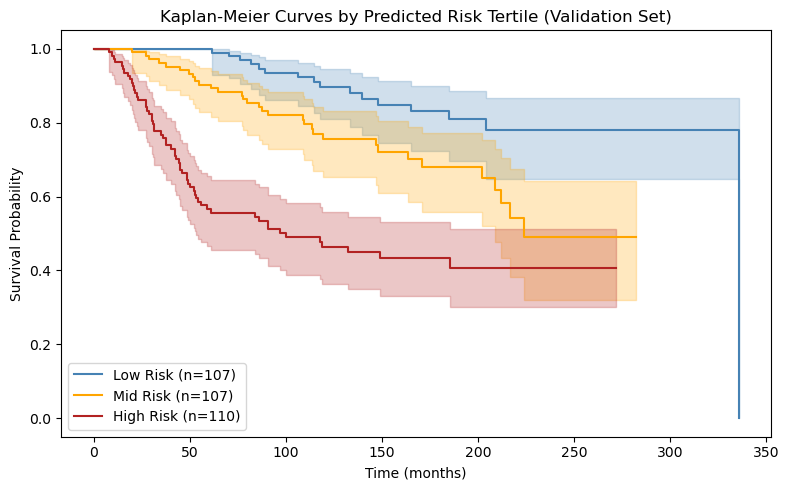

In [79]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

# Split into risk tertiles
tertiles = np.percentile(val_risk, [33, 66])
risk_group = np.digitize(val_risk, tertiles)  # 0=low, 1=mid, 2=high

# KM curves
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for group, label, color in zip(
    [0, 1, 2],
    ["Low Risk", "Mid Risk", "High Risk"],
    ["steelblue", "orange", "firebrick"]
):
    mask = risk_group == group
    kmf.fit(time_val[mask], event_val[mask], label=f"{label} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier Curves by Predicted Risk Tertile (Validation Set)")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

### Multivariate Log-Rank Test

The log-rank test formally tests whether the survival curves across predicted
risk groups are **statistically distinguishable** from one another, or whether
the observed differences could be due to random chance.

#### Null Hypothesis

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

Under $H_0$, group membership has no effect on survival — deaths are distributed
proportionally to group size at every time point.

#### Setup

Let there be $K$ groups and $M$ distinct event times $t_1 < t_2 < \cdots < t_M$.

At each event time $t_j$, define:

- $d_{jk}$ = observed deaths in group $k$ at time $t_j$
- $n_{jk}$ = patients at risk in group $k$ just before $t_j$
- $d_j = \sum_k d_{jk}$ = total deaths at $t_j$
- $n_j = \sum_k n_{jk}$ = total patients at risk at $t_j$

#### Expected Deaths

Under $H_0$, the expected number of deaths in group $k$ at time $t_j$ is:

$$
e_{jk} = n_{jk} \times \frac{d_j}{n_j}
$$

That is, each group's share of the at-risk pool, multiplied by the total
number of deaths at that time point.

#### Observed Minus Expected

For each group $k$, accumulate the difference between observed and expected
deaths across all event times:

$$
U_k = \sum_{j=1}^{M} (d_{jk} - e_{jk})
$$

Collected into a vector of length $K-1$ (the last group is determined by the others
since $\sum_k U_k = 0$):

$$
\mathbf{U} = [U_1, U_2, \ldots, U_{K-1}]^\top
$$

#### Variance-Covariance Matrix

The variance of $U_k$ and covariance between groups $k$ and $l$ at each event
time come from the hypergeometric distribution. Summing across all event times:

$$
V_{kk} = \sum_{j=1}^{M} \frac{n_{jk}(n_j - n_{jk}) \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
$$

$$
V_{kl} = -\sum_{j=1}^{M} \frac{n_{jk} \cdot n_{jl} \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
\quad k \neq l
$$

This gives the full $(K-1) \times (K-1)$ variance-covariance matrix $\mathbf{V}$.

#### Test Statistic

The test statistic is the quadratic form:

$$
\chi^2 = \mathbf{U}^\top \mathbf{V}^{-1} \mathbf{U}
$$

Under $H_0$, this follows a **chi-squared distribution** with $K-1$ degrees
of freedom. For three risk groups ($K=3$), this gives $df = 2$.

#### P-value

$$
p = P(\chi^2_{K-1} \geq \chi^2_{\text{observed}})
$$

A small p-value indicates the observed survival differences are unlikely
under $H_0$, and we reject the hypothesis that all groups have equal survival.

#### Interpretation

| Result | Meaning |
|--------|---------|
| $p < 0.05$ | Survival curves are significantly different across groups |
| $p \geq 0.05$ | No significant difference detected |
| Large $\chi^2$, small $p$ | Strong evidence of risk stratification |
| $U_k \gg 0$ for low risk | Fewer deaths than expected — model correctly identified survivors |
| $U_k \ll 0$ for high risk | More deaths than expected — model correctly identified high risk patients |

#### Assumptions

- **Proportional hazards:** the relative difference between groups is consistent
  over time. If KM curves cross, this assumption is violated and the log-rank
  test loses statistical power
- **Independent censoring:** censoring is unrelated to the probability of the event
- **Large sample:** the $\chi^2$ approximation holds when event counts are not too small

> **Note:** The log-rank test confirms *statistical significance* of group separation
> but not *effect size*. A significant p-value with overlapping KM curves (common in
> large samples) may not be clinically meaningful. Always interpret alongside the
> KM plot and hazard ratios.

In [80]:
# Log-rank test
logrank = multivariate_logrank_test(time_val, risk_group, event_val)
print(f"Log-rank p-value: {logrank.p_value:.4f}")
logrank.print_summary()

Log-rank p-value: 0.0000


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          55.03 <0.005     39.70

### Integrated Brier Score

#### Brier Score measures calibration: 
##### If the model predicts a patient has a 70% chance of surviving for 5 years, are ~70% of patients alive after 5 years? 

Brier Score evaluates the accuracy of the predicted survival function at a given time t. 

Represents average squared distances between observed survival status and predicted survival probability, and is always between 0 and 1 (0 is best possible value).

## Integrated Brier Score

The Brier Score at a single time point $t$ is:

$$
BS(t) = \frac{1}{n} \sum_{i=1}^{n} \left[
    \frac{\mathbf{1}(T_i \leq t,\, \delta_i = 1)}{\hat{G}(T_i)} \cdot \hat{S}_i(t)^2
    + \frac{\mathbf{1}(T_i > t)}{\hat{G}(t)} \cdot (1 - \hat{S}_i(t))^2
\right]
$$

Where:
- $\hat{S}_i(t)$ = predicted survival probability for patient $i$ at time $t$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{G}(t)$ = Kaplan-Meier estimate of the censoring distribution (IPCW weight)

The **Integrated Brier Score** averages $BS(t)$ over a time range $[t_{min}, t_{max}]$:

$$
\text{IBS} = \frac{1}{t_{max} - t_{min}} \int_{t_{min}}^{t_{max}} BS(t)\, dt
$$

In our case, we stop evaluation after the 90th percentile because survival estimates become unreliable in the tail where few patients remain at risk

| IBS | Interpretation |
|-----|---------------|
| $< 0.15$ | Good calibration |
| $0.25$ | Uninformative (null model) |
| $> 0.25$ | Worse than no predictors |

In [81]:
def compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val):
    """
    Compute the Integrated Brier Score for a survival model.

    Parameters:
        train_risk  : np.array — risk scores for training set
        val_risk    : np.array — risk scores for validation/test set
        surv_train  : structured array — training survival data (event, time)
        surv_val    : structured array — validation survival data (event, time)
        time_val    : np.array — survival times for validation/test set

    Returns:
        ibs : float — Integrated Brier Score
    """
    from sksurv.metrics import integrated_brier_score
    from sksurv.linear_model import CoxPHSurvivalAnalysis

    # Fit Cox reference on training risk scores to get baseline hazard
    cox_ref = CoxPHSurvivalAnalysis()
    cox_ref.fit(train_risk.reshape(-1, 1), surv_train)

    # Time grid within observed range
    times_ibs = np.linspace(
        time_val.min() + 1,
        np.percentile(time_val, 90),
        100
    )

    # Get survival probabilities for each patient at each time point
    surv_fns = cox_ref.predict_survival_function(val_risk.reshape(-1, 1))
    surv_probs = np.vstack([fn(times_ibs) for fn in surv_fns])

    ibs = integrated_brier_score(surv_train, surv_val, surv_probs, times_ibs)
    return ibs

In [82]:
ibs = compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val)
print(f"Integrated Brier Score: {ibs:.4f}")

Integrated Brier Score: 0.1450


### Time-Dependent AUC

The standard C-index summarizes discrimination across all time points in a
single number. Time-dependent AUC extends this by asking: **how well does
the model discriminate survival at each specific time point?** This is
particularly useful for identifying whether the model performs better at
predicting short-term versus long-term survival.

#### Defining Cases and Controls at Time $t$

At each time point $t$, patients are classified as:

- **Case:** patient $i$ experienced the event before $t$, i.e. $T_i \leq t$ and $\delta_i = 1$
- **Control:** patient $j$ survived past $t$, i.e. $T_j > t$

This classification changes at every time point — a patient who is a control
at $t = 12$ months may become a case at $t = 36$ months.

#### AUC at a Single Time Point

For a given time $t$, the AUC measures the probability that a randomly
selected case has a higher predicted risk score than a randomly selected
control:

$$
\text{AUC}(t) = P\left(\hat{r}_i > \hat{r}_j \mid T_i \leq t,\, \delta_i = 1,\, T_j > t\right)
$$

Where:
- $\hat{r}_i$ = predicted risk score for patient $i$
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)

This is equivalent to the area under the ROC curve at time $t$, where the
ROC curve is constructed by varying the risk score threshold and plotting:

$$
\text{Sensitivity}(t) = P(\hat{r}_i > c \mid T_i \leq t,\,\delta_i = 1)
$$

$$
1 - \text{Specificity}(t) = P(\hat{r}_j > c \mid T_j > t)
$$

#### Handling Censoring with IPCW

Censored patients create ambiguity — a patient censored at $t = 24$ months
cannot be classified as a case or control at $t = 36$ months. This is
resolved using **Inverse Probability of Censoring Weighting (IPCW)**,
which reweights the contribution of each patient by the inverse probability
of not being censored:

$$
\text{AUC}(t) = \frac{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{\mathbf{1}(\hat{r}_i > \hat{r}_j)}{\hat{G}(T_i)\,\hat{G}(t)}
}{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{1}{\hat{G}(T_i)\,\hat{G}(t)}
}
$$

Where $\hat{G}(t)$ is the Kaplan-Meier estimate of the censoring distribution.
Patients who were likely to be censored receive higher weights, compensating
for their underrepresentation in the observed data.

#### Cumulative vs. Incident AUC

There are two common definitions of cases and controls:

$$
\text{Cumulative/Dynamic AUC: cases are } \{i : T_i \leq t,\, \delta_i = 1\}
$$

$$
\text{Incident/Dynamic AUC: cases are } \{i : T_i = t,\, \delta_i = 1\}
$$

**Cumulative AUC** (used by `sksurv`) accumulates all deaths up to $t$ as
cases — this is more stable because it uses more events per time point,
especially useful when events are rare at any single time.

#### Mean AUC

To summarize discrimination across all evaluated time points
$t_1, t_2, \ldots, t_M$, the mean AUC weights each time point by the
proportion of total events occurring up to that time:

$$
\overline{\text{AUC}} = \frac{1}{\hat{S}(t_{\min}) - \hat{S}(t_{\max})}
\int_{t_{\min}}^{t_{\max}} \text{AUC}(t)\, d\hat{F}(t)
$$

Where $\hat{F}(t) = 1 - \hat{S}(t)$ is the estimated marginal event
probability. In practice this integral is approximated over the discrete
set of evaluation time points.

#### Evaluated Time Points

In your model, AUC is evaluated at clinically meaningful time points:

| Time Point | Clinical Relevance |
|------------|--------------------|
| $t = 12$ months | 1-year survival |
| $t = 36$ months | 3-year survival |
| $t = 60$ months | 5-year survival |
| $t = 84$ months | 7-year survival |

#### Interpretation

| AUC$(t)$ | Meaning |
|----------|---------|
| $1.0$ | Perfect discrimination at time $t$ |
| $0.5$ | Random chance — no better than a coin flip |
| $< 0.5$ | Inverted predictions |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

A **declining AUC over time** is expected and normal — short-term risk
is generally easier to predict than long-term risk, as the influence of
measured clinical features weakens over longer follow-up periods.

#### Relationship to C-index

The C-index can be seen as a weighted average of $\text{AUC}(t)$ across
all event times, whereas time-dependent AUC resolves *when* discrimination
is strongest. A model with a moderate C-index may still have high AUC at
clinically critical time points such as 1-year or 5-year survival.

> **Note:** Time-dependent AUC measures *discrimination* — whether the model
> correctly ranks cases above controls at each time point. Like the C-index,
> it does not measure calibration. Always report alongside the Integrated
> Brier Score for a complete picture of model performance.


Time-dependent AUC:
  1-year AUC (12mo): 0.9549
  3-year AUC (36mo): 0.8631
  5-year AUC (60mo): 0.8621
  7-year AUC (84mo): 0.8005
  Mean AUC: 0.8579


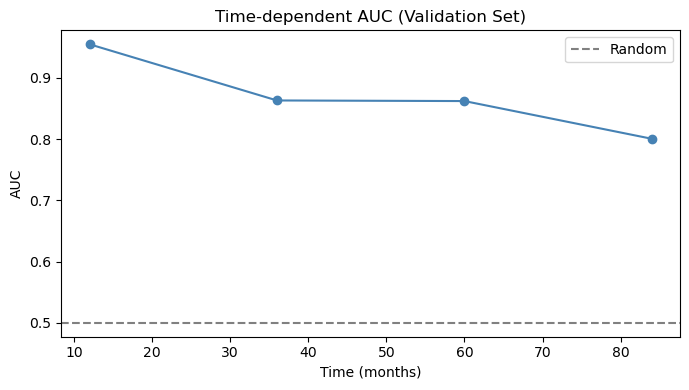

In [83]:
from sksurv.metrics import cumulative_dynamic_auc

# Clinically meaningful time points for breast cancer (months)
eval_times = [12, 36, 60, 84]  # 1, 3, 5, 7 years

# Filter to times within observed range
max_time = np.percentile(time_val, 90)
eval_times = [t for t in eval_times if t < max_time]

auc_scores, mean_auc = cumulative_dynamic_auc(
    surv_train, surv_val,
    val_risk,  # negative because higher risk = lower survival
    eval_times
)

print(f"\nTime-dependent AUC:")
for t, auc in zip(eval_times, auc_scores):
    years = t // 12
    print(f"  {years}-year AUC ({t}mo): {auc:.4f}")
print(f"  Mean AUC: {mean_auc:.4f}")

# Plot AUC over time
plt.figure(figsize=(7, 4))
plt.plot(eval_times, auc_scores, marker='o', color='steelblue')
plt.axhline(0.5, linestyle='--', color='gray', label='Random')
plt.xlabel("Time (months)")
plt.ylabel("AUC")
plt.title("Time-dependent AUC (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation Metrics Wrapped Together

In [84]:
def evaluate_model(model, X_tensor, time_arr, event_arr, surv_train,
                   train_risk=None, label="Validation"):
    """
    Evaluate a survival model with C-index, time-dependent AUC, and IBS.

    Parameters:
        model       : torch.nn.Module — trained survival model
        X_tensor    : torch.Tensor — input features
        time_arr    : np.array — survival times
        event_arr   : np.array — event indicators (1=event, 0=censored)
        surv_train  : structured array — training survival data for IBS/AUC reference
        train_risk  : np.array, optional — training risk scores needed for IBS.
                      If None, IBS is skipped.
                      This is to compute the baseline hazard for Brier score calculation.
        label       : str — label for printed output (e.g. "Validation", "Test")

    Returns:
        dict with c_index, mean_auc, auc_by_time, and ibs (if computed)
    """
    model.eval()
    with torch.no_grad():
        risk = model(X_tensor).numpy()

    surv_arr = make_structured_array(event_arr, time_arr)

    # C-index
    ci = concordance_index(time_arr, -risk, event_arr)

    # Time-dependent AUC
    max_t = np.percentile(time_arr, 90)
    eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
    auc_scores, mean_auc = cumulative_dynamic_auc(surv_train, surv_arr, risk, eval_times)

    # Integrated Brier Score (only if train_risk provided)
    ibs = None
    if train_risk is not None:
        ibs = compute_ibs(train_risk, risk, surv_train, surv_arr, time_arr)

    # Print results
    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    print(f"  C-index:        {ci:.4f}")
    print(f"  Mean AUC:       {mean_auc:.4f}")
    for t, auc in zip(eval_times, auc_scores):
        print(f"    AUC @ {t:>3}mo:  {auc:.4f}")
    if ibs is not None:
        print(f"  Brier Score:    {ibs:.4f}  (< 0.15 good, 0.25 = uninformative)")

    results = {
        "c_index":      ci,
        "mean_auc":     mean_auc,
        "auc_by_time":  dict(zip(eval_times, auc_scores)),
        "ibs":          ibs
    }
    return results

# Validation and Test Results

In [85]:
# Compute train risk scores once after training
model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()

# Evaluate with all metrics
val_results  = evaluate_model(model, X_val_tensor,  time_val,  event_val,
                               surv_train, train_risk=train_risk, label="Validation")

test_results = evaluate_model(model, X_test_tensor, time_test, event_test,
                               surv_train, train_risk=train_risk, label="Test")


  Validation Results
  C-index:        0.7531
  Mean AUC:       0.8579
    AUC @  12mo:  0.9549
    AUC @  36mo:  0.8631
    AUC @  60mo:  0.8621
    AUC @  84mo:  0.8005
  Brier Score:    0.1450  (< 0.15 good, 0.25 = uninformative)

  Test Results
  C-index:        0.7182
  Mean AUC:       0.7817
    AUC @  12mo:  0.8250
    AUC @  36mo:  0.7872
    AUC @  60mo:  0.7720
    AUC @  84mo:  0.7770
  Brier Score:    0.1474  (< 0.15 good, 0.25 = uninformative)


## 2. Cross Validation Comparing Clinical, Clinical + Expression, and Clinical + Expression Autoencoder (Without Mutation)

In [86]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index
from sksurv.metrics import cumulative_dynamic_auc
import numpy as np
import torch

set_seed(42)

# ── Model factory functions ───────────────────────────────────────
# These return a fresh model each fold

def make_clinical_model(input_dim):
    return ClinicalSurvNet(input_dim)

def make_expr_model(input_dim, expr_dim):
    return ClinicalExprSurvNet(input_dim, expr_dim)

def make_ae_model(input_dim, pretrained_encoder):
    return ClinicalExprAESurvNet(input_dim, pretrained_encoder)

def compute_cindex(model, time_array, event_array, *input_tensors):
    """
    Compute concordance index for any model regardless of number of inputs.
    Accepts both torch.Tensors and np.arrays as input.
    """
    model.eval()
    with torch.no_grad():
        # Convert any numpy arrays to tensors
        tensor_inputs = [
            torch.tensor(x, dtype=torch.float32)
            if isinstance(x, np.ndarray) else x
            for x in input_tensors
        ]
        risk_scores = model(*tensor_inputs).numpy()
    return concordance_index(time_array, -risk_scores, event_array)

# ── Core CV function ──────────────────────────────────────────────
def run_cross_validation(
    model_type,         # "clinical", "expr", or "ae"
    X_raw,              # unscaled clinical features (np.array)
    time_arr,           # survival times
    event_arr,          # event indicators
    expr_raw=None,      # unscaled expression data (np.array), optional
    ae_encoder=None,    # pretrained AE encoder for "ae" model type
    n_folds=5,
    seed=42,
    patience=50,
    max_epochs=1000
):
    """
    Run stratified k-fold cross-validation for a survival model.

    Parameters:
        model_type      : str — one of "clinical", "expr", "ae"
        X_raw           : np.array — unscaled clinical features
        time_arr        : np.array — survival times
        event_arr       : np.array — event indicators
        expr_raw        : np.array — unscaled expression features (required
                          for "expr" and "ae" model types)
        ae_encoder      : pretrained encoder module (required for "ae")
        n_folds         : int — number of CV folds
        seed            : int — random seed
        patience        : int — early stopping patience (in eval steps)
        max_epochs      : int — maximum training epochs

    Returns:
        results : dict with lists of metrics per fold
        fold_details : list of dicts with per-fold full metrics
    """
    assert model_type in ("clinical", "expr", "ae"), \
        "model_type must be 'clinical', 'expr', or 'ae'"
    if model_type in ("expr", "ae"):
        assert expr_raw is not None, \
            "expr_raw required for expr and ae model types"
    if model_type == "ae":
        assert ae_encoder is not None, \
            "ae_encoder required for ae model type"

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    results = {"c_index": [], "mean_auc": [], "ibs": []}
    fold_details = []

    for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_raw, event_arr)
    ):
        print(f"\n  Fold {fold+1}/{n_folds}")

        # ── Split and scale clinical features ─────────────────────
        X_tr_raw = X_raw[train_idx].astype(np.float32)
        X_te_raw = X_raw[test_idx].astype(np.float32)
        t_tr = time_arr[train_idx]
        t_te = time_arr[test_idx]
        e_tr = event_arr[train_idx]
        e_te = event_arr[test_idx]

        # Impute then scale within fold
        fold_imputer = SimpleImputer(strategy="median")
        X_tr_raw = fold_imputer.fit_transform(X_tr_raw)
        X_te_raw = fold_imputer.transform(X_te_raw)

        clin_scaler = StandardScaler()
        X_tr = clin_scaler.fit_transform(X_tr_raw)
        X_te = clin_scaler.transform(X_te_raw)

        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        X_te_t = torch.tensor(X_te, dtype=torch.float32)
        t_tr_t = torch.tensor(t_tr, dtype=torch.float32)
        e_tr_t = torch.tensor(e_tr, dtype=torch.float32)

        # ── Split and scale expression features (if needed) ───────
        if model_type in ("expr", "ae"):
            expr_tr_raw = expr_raw[train_idx].astype(np.float32)
            expr_te_raw = expr_raw[test_idx].astype(np.float32)

            expr_scaler = StandardScaler()
            expr_tr = expr_scaler.fit_transform(expr_tr_raw)
            expr_te = expr_scaler.transform(expr_te_raw)

            expr_tr_t = torch.tensor(expr_tr, dtype=torch.float32)
            expr_te_t = torch.tensor(expr_te, dtype=torch.float32)

        # ── Build model ───────────────────────────────────────────
        clin_dim = X_tr_t.shape[1]

        if model_type == "clinical":
            model = make_clinical_model(clin_dim)
            optimizer = torch.optim.Adam(
                model.parameters(), lr=1e-3, weight_decay=1e-4
            )
            train_inputs = [X_tr_t]
            test_inputs  = [X_te_t]

        elif model_type == "expr":
            expr_dim = expr_tr_t.shape[1]
            model = make_expr_model(clin_dim, expr_dim)
            optimizer = torch.optim.Adam([
                {"params": model.clin_enc.parameters(), "lr": 1e-3},
                {"params": model.expr_enc.parameters(), "lr": 1e-4},
                {"params": model.head.parameters(),     "lr": 1e-3}
            ], weight_decay=1e-3)
            train_inputs = [X_tr_t, expr_tr_t]
            test_inputs  = [X_te_t, expr_te_t]

        elif model_type == "ae":
            # Deep copy encoder so each fold gets fresh weights
            import copy
            fold_encoder = copy.deepcopy(ae_encoder)
            model = make_ae_model(clin_dim, fold_encoder)
            optimizer = torch.optim.Adam([
                {"params": model.clin_enc.parameters(), "lr": 1e-3},
                {"params": model.expr_enc.parameters(), "lr": 1e-5},
                {"params": model.head.parameters(),     "lr": 1e-3}
            ], weight_decay=1e-3)
            train_inputs = [X_tr_t, expr_tr_t]
            test_inputs  = [X_te_t, expr_te_t]

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=20, min_lr=1e-7
        )

        # ── Training loop with early stopping ─────────────────────
        best_ci     = 0
        best_w      = None
        no_improve  = 0

        for epoch in range(max_epochs):
            model.train()
            optimizer.zero_grad()
            risk = model(*train_inputs)
            loss = cox_loss(risk, t_tr_t, e_tr_t)
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                val_ci = compute_cindex(
                    model, t_te, e_te,
                    *[x if isinstance(x, torch.Tensor) else
                    torch.tensor(x, dtype=torch.float32)
                    for x in test_inputs]
                )
                scheduler.step(val_ci)

                if val_ci > best_ci:
                    best_ci = val_ci
                    best_w  = {
                        k: v.clone()
                        for k, v in model.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1

                if no_improve >= patience:
                    break

        model.load_state_dict(best_w)
        model.eval()

        # ── Evaluate fold ─────────────────────────────────────────
        surv_tr = make_structured_array(e_tr, t_tr)
        surv_te = make_structured_array(e_te, t_te)

        with torch.no_grad():
            risk_tr = model(*train_inputs).numpy()
            risk_te = model(*test_inputs).numpy()

        ci = concordance_index(t_te, -risk_te, e_te)

        max_t = np.percentile(t_te, 90)
        eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
        auc_scores, mean_auc = cumulative_dynamic_auc(
            surv_tr, surv_te, risk_te, eval_times
        )

        ibs = compute_ibs(risk_tr, risk_te, surv_tr, surv_te, t_te)

        results["c_index"].append(ci)
        results["mean_auc"].append(mean_auc)
        results["ibs"].append(ibs)

        fold_detail = {
            "fold":        fold + 1,
            "c_index":     ci,
            "mean_auc":    mean_auc,
            "ibs":         ibs,
            "auc_by_time": dict(zip(eval_times, auc_scores)),
            "n_train":     len(train_idx),
            "n_test":      len(test_idx),
        }
        fold_details.append(fold_detail)

        print(f"    C-index: {ci:.4f} | "
              f"AUC: {mean_auc:.4f} | "
              f"IBS: {ibs:.4f}")

    return results, fold_details

# ── Comparison function ───────────────────────────────────────────
def compare_cv_results(results_dict):
    """
    Print a comparison table of cross-validation results across models.

    Parameters:
        results_dict : dict of {model_name: (results, fold_details)}
    """
    metrics = ["c_index", "mean_auc", "ibs"]
    metric_labels = {"c_index": "C-index", "mean_auc": "Mean AUC", "ibs": "IBS"}
    ibs_note = {"c_index": "(higher better)",
                "mean_auc": "(higher better)",
                "ibs": "(lower better)"}

    model_names = list(results_dict.keys())

    print(f"\n{'='*70}")
    print(f"  Cross-Validation Comparison ({len(list(results_dict.values())[0][1])} folds)")
    print(f"{'='*70}")

    # Header
    header = f"  {'Metric':<18}"
    for name in model_names:
        header += f"  {name:>18}"
    print(header)
    print(f"  {'-'*68}")

    # Metrics
    for metric in metrics:
        row = f"  {metric_labels[metric]:<18}"
        for name in model_names:
            results, _ = results_dict[name]
            vals = results[metric]
            mean = np.mean(vals)
            std  = np.std(vals)
            row += f"  {mean:.4f} ± {std:.4f}"
        print(row)
        print(f"  {'  ' + ibs_note[metric]:<18}")

    # Per-fold detail
    print(f"\n{'='*70}")
    print(f"  Per-fold C-index")
    print(f"{'='*70}")

    header = f"  {'Fold':<8}"
    for name in model_names:
        header += f"  {name:>18}"
    print(header)
    print(f"  {'-'*68}")

    n_folds = len(list(results_dict.values())[0][1])
    for fold_i in range(n_folds):
        row = f"  {fold_i+1:<8}"
        for name in model_names:
            _, fold_details = results_dict[name]
            ci = fold_details[fold_i]["c_index"]
            row += f"  {ci:>18.4f}"
        print(row)

    # Which model wins each fold
    print(f"\n{'='*70}")
    print(f"  Fold Winners (C-index)")
    print(f"{'='*70}")
    wins = {name: 0 for name in model_names}
    for fold_i in range(n_folds):
        fold_cis = {
            name: results_dict[name][1][fold_i]["c_index"]
            for name in model_names
        }
        winner = max(fold_cis, key=fold_cis.get)
        wins[winner] += 1
        print(f"  Fold {fold_i+1}: {winner} "
              f"({fold_cis[winner]:.4f})")

    print(f"\n  Wins: " +
          ", ".join([f"{name}: {w}/{n_folds}"
                     for name, w in wins.items()]))

In [87]:
# Rebuild X_raw cleanly as pure numpy
num_imputer_raw = SimpleImputer(strategy="median")
X_num_raw = num_imputer_raw.fit_transform(X[numeric_cols].values)

X_cat_raw = pd.get_dummies(
    X[categorical_cols].fillna("Unknown"),
    drop_first=True
).values.astype(np.float32)

X_raw = np.hstack([
    X_num_raw.astype(np.float32),
    X_cat_raw
])

print(f"X_raw shape: {X_raw.shape}")
print(f"X_raw dtype: {X_raw.dtype}")
# Should be float32 with no NaNs
print(f"NaNs in X_raw: {np.isnan(X_raw).sum()}")

X_raw shape: (1904, 29)
X_raw dtype: float32
NaNs in X_raw: 0


In [88]:
# Use the already-cleaned X_raw from the cell above
# (with num_imputer_raw applied — no NaNs)
# Just need to rebuild with get_dummies using fillna for categoricals

X_cat_raw = pd.get_dummies(
    X[categorical_cols].fillna("Unknown"),
    drop_first=True
).values.astype(np.float32)

X_raw = np.hstack([
    X_num_raw.astype(np.float32),  # already imputed above
    X_cat_raw
])

print(f"X_raw shape: {X_raw.shape}")
print(f"NaNs in X_raw: {np.isnan(X_raw).sum()}")
# Must be 0 before proceeding

X_raw shape: (1904, 29)
NaNs in X_raw: 0


In [89]:
# ── Run CV for all three models ───────────────────────────────────

# raw expression data
expr_raw = expression_data.values.astype(np.float32)

print("=" * 50)
print("Running CV: Clinical Only")
print("=" * 50)
cv_clinical, folds_clinical = run_cross_validation(
    model_type="clinical",
    X_raw=X_raw,
    time_arr=y_time,
    event_arr=y_event,
    n_folds=5,
    seed=42
)

print("\n" + "=" * 50)
print("Running CV: Clinical + Expression Encoder")
print("=" * 50)
cv_expr, folds_expr = run_cross_validation(
    model_type="expr",
    X_raw=X_raw,
    time_arr=y_time,
    event_arr=y_event,
    expr_raw=expr_raw,
    n_folds=5,
    seed=42
)

print("\n" + "=" * 50)
print("Running CV: Clinical + Expression Autoencoder")
print("=" * 50)
cv_ae, folds_ae = run_cross_validation(
    model_type="ae",
    X_raw=X_raw,
    time_arr=y_time,
    event_arr=y_event,
    expr_raw=expr_raw,
    ae_encoder=ae.encoder,  # pretrained autoencoder encoder
    n_folds=5,
    seed=42
)

# ── Compare all three ─────────────────────────────────────────────
compare_cv_results({
    "Clinical":    (cv_clinical, folds_clinical),
    "Clin+Expr":   (cv_expr,     folds_expr),
    "Clin+ExprAE": (cv_ae,       folds_ae),
})

Running CV: Clinical Only

  Fold 1/5
    C-index: 0.7060 | AUC: 0.7829 | IBS: 0.1599

  Fold 2/5
    C-index: 0.7264 | AUC: 0.8087 | IBS: 0.1477

  Fold 3/5
    C-index: 0.6987 | AUC: 0.7481 | IBS: 0.1433

  Fold 4/5
    C-index: 0.6822 | AUC: 0.7332 | IBS: 0.1613

  Fold 5/5
    C-index: 0.7353 | AUC: 0.7945 | IBS: 0.1439

Running CV: Clinical + Expression Encoder

  Fold 1/5
    C-index: 0.7235 | AUC: 0.8096 | IBS: 0.1596

  Fold 2/5
    C-index: 0.7402 | AUC: 0.8180 | IBS: 0.1575

  Fold 3/5
    C-index: 0.7136 | AUC: 0.7556 | IBS: 0.1645

  Fold 4/5
    C-index: 0.6880 | AUC: 0.7203 | IBS: 0.1658

  Fold 5/5
    C-index: 0.7567 | AUC: 0.8120 | IBS: 0.1375

Running CV: Clinical + Expression Autoencoder

  Fold 1/5
    C-index: 0.7090 | AUC: 0.7810 | IBS: 0.1634

  Fold 2/5
    C-index: 0.7364 | AUC: 0.8126 | IBS: 0.1455

  Fold 3/5
    C-index: 0.7211 | AUC: 0.7842 | IBS: 0.1401

  Fold 4/5
    C-index: 0.6869 | AUC: 0.7365 | IBS: 0.1652

  Fold 5/5
    C-index: 0.7431 | AUC: 0.795

### Cross-Fold Validation Interpretation

- Expression data adds real signal, across all folds. Clinical + Expression Encoders outperform Clinical only encoders
- Expression Autoencoder outperformed the standard expression encoder across 3 of 5 folds in C-index, maintained a higher mean AUC, and lower mean IBS
- Expression Autoencoder also maintained lower variance. This makes sense as the standard encoder has to learn representation and survival simultaneously 

In [90]:
# Store this as the best model choice
best_expr_model = "Clin+ExprAE"

## Next: Add mutation information to clinical features, and test 3-way CV 

In [91]:
# ── Step 1: Build augmented clinical + mutation feature matrix ────

# Frequent mutation genes (mutated in >5% of patients)
mut_frequent_raw = mutation_binary[frequent_genes].values.astype(np.float32)

# TMB (raw counts — scaling happens inside CV)
tmb_raw = mutation_binary.sum(axis=1).values.astype(np.float32).reshape(-1, 1)

# Augmented raw feature matrix: clinical + frequent mutations + TMB
X_raw_mut = np.hstack([X_raw, mut_frequent_raw, tmb_raw])

print(f"Clinical only shape:      {X_raw.shape}")
print(f"Augmented + mut shape:    {X_raw_mut.shape}")
print(f"NaNs in X_raw_mut:        {np.isnan(X_raw_mut).sum()}")
# Expected: (1904, 55) — 29 clinical + 25 mutations + 1 TMB

Clinical only shape:      (1904, 29)
Augmented + mut shape:    (1904, 55)
NaNs in X_raw_mut:        0


In [92]:
# ── Step 2: Add augmented clinical model to model factory ─────────

def make_clinical_mut_model(input_dim):
    """ClinicalSurvNet with augmented clinical + mutation input"""
    return ClinicalSurvNet(input_dim)

# No architecture change needed — ClinicalSurvNet already
# takes input_dim as argument, so the larger feature vector
# is handled automatically

In [93]:
# ── Step 3: Extend run_cross_validation to support aug clinical ───
# Add "clinical_mut" and "ae_mut" as new model types

def run_cross_validation(
    model_type,
    X_raw,
    time_arr,
    event_arr,
    expr_raw=None,
    ae_encoder=None,
    n_folds=5,
    seed=42,
    patience=50,
    max_epochs=1000
):
    """
    Run stratified k-fold cross-validation for a survival model.

    model_type options:
        "clinical"     — clinical features only
        "clinical_mut" — clinical + frequent mutations + TMB
        "expr"         — clinical + expression supervised encoder
        "ae"           — clinical + expression autoencoder
        "ae_mut"       — clinical + mutation + expression autoencoder
    """
    valid_types = ("clinical", "clinical_mut", "expr", "ae", "ae_mut")
    assert model_type in valid_types, \
        f"model_type must be one of {valid_types}"
    if model_type in ("expr", "ae", "ae_mut"):
        assert expr_raw is not None, \
            "expr_raw required for expr, ae, ae_mut model types"
    if model_type in ("ae", "ae_mut"):
        assert ae_encoder is not None, \
            "ae_encoder required for ae and ae_mut model types"

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    results = {"c_index": [], "mean_auc": [], "ibs": []}
    fold_details = []

    for fold, (train_idx, test_idx) in enumerate(
        skf.split(X_raw, event_arr)
    ):
        print(f"\n  Fold {fold+1}/{n_folds}")

        # ── Split clinical (or augmented clinical) features ───────
        X_tr_raw = X_raw[train_idx].astype(np.float32)
        X_te_raw = X_raw[test_idx].astype(np.float32)
        t_tr = time_arr[train_idx]
        t_te = time_arr[test_idx]
        e_tr = event_arr[train_idx]
        e_te = event_arr[test_idx]

        # Impute then scale within fold
        fold_imputer = SimpleImputer(strategy="median")
        X_tr_raw = fold_imputer.fit_transform(X_tr_raw)
        X_te_raw = fold_imputer.transform(X_te_raw)

        clin_scaler = StandardScaler()
        X_tr = clin_scaler.fit_transform(X_tr_raw)
        X_te = clin_scaler.transform(X_te_raw)

        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        X_te_t = torch.tensor(X_te, dtype=torch.float32)
        t_tr_t = torch.tensor(t_tr, dtype=torch.float32)
        e_tr_t = torch.tensor(e_tr, dtype=torch.float32)

        # ── Split and scale expression features (if needed) ───────
        if model_type in ("expr", "ae", "ae_mut"):
            expr_tr_raw = expr_raw[train_idx].astype(np.float32)
            expr_te_raw = expr_raw[test_idx].astype(np.float32)

            expr_scaler = StandardScaler()
            expr_tr = expr_scaler.fit_transform(expr_tr_raw)
            expr_te = expr_scaler.transform(expr_te_raw)

            expr_tr_t = torch.tensor(expr_tr, dtype=torch.float32)
            expr_te_t = torch.tensor(expr_te, dtype=torch.float32)

        # ── Build model and set inputs ────────────────────────────
        clin_dim = X_tr_t.shape[1]

        if model_type in ("clinical", "clinical_mut"):
            # Both use ClinicalSurvNet — input_dim differs automatically
            model = ClinicalSurvNet(clin_dim)
            optimizer = torch.optim.Adam(
                model.parameters(), lr=1e-3, weight_decay=1e-4
            )
            train_inputs = [X_tr_t]
            test_inputs  = [X_te_t]

        elif model_type == "expr":
            expr_dim = expr_tr_t.shape[1]
            model = ClinicalExprSurvNet(clin_dim, expr_dim)
            optimizer = torch.optim.Adam([
                {"params": model.clin_enc.parameters(), "lr": 1e-3},
                {"params": model.expr_enc.parameters(), "lr": 1e-4},
                {"params": model.head.parameters(),     "lr": 1e-3}
            ], weight_decay=1e-3)
            train_inputs = [X_tr_t, expr_tr_t]
            test_inputs  = [X_te_t, expr_te_t]

        elif model_type in ("ae", "ae_mut"):
            import copy
            fold_encoder = copy.deepcopy(ae_encoder)
            model = ClinicalExprAESurvNet(clin_dim, fold_encoder)
            optimizer = torch.optim.Adam([
                {"params": model.clin_enc.parameters(), "lr": 1e-3},
                {"params": model.expr_enc.parameters(), "lr": 1e-5},
                {"params": model.head.parameters(),     "lr": 1e-3}
            ], weight_decay=1e-3)
            train_inputs = [X_tr_t, expr_tr_t]
            test_inputs  = [X_te_t, expr_te_t]

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=20, min_lr=1e-7
        )

        # ── Training loop ─────────────────────────────────────────
        best_ci    = 0
        best_w     = None
        no_improve = 0

        for epoch in range(max_epochs):
            model.train()
            optimizer.zero_grad()
            risk = model(*train_inputs)
            loss = cox_loss(risk, t_tr_t, e_tr_t)
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                val_ci = compute_cindex(
                    model, t_te, e_te, *test_inputs
                )
                scheduler.step(val_ci)

                if val_ci > best_ci:
                    best_ci = val_ci
                    best_w  = {
                        k: v.clone()
                        for k, v in model.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1

                if no_improve >= patience:
                    break

        model.load_state_dict(best_w)
        model.eval()

        # ── Evaluate fold ─────────────────────────────────────────
        surv_tr = make_structured_array(e_tr, t_tr)
        surv_te = make_structured_array(e_te, t_te)

        with torch.no_grad():
            risk_tr = model(*train_inputs).numpy()
            risk_te = model(*test_inputs).numpy()

        ci = concordance_index(t_te, -risk_te, e_te)

        max_t = np.percentile(t_te, 90)
        eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
        auc_scores, mean_auc = cumulative_dynamic_auc(
            surv_tr, surv_te, risk_te, eval_times
        )
        ibs = compute_ibs(risk_tr, risk_te, surv_tr, surv_te, t_te)

        results["c_index"].append(ci)
        results["mean_auc"].append(mean_auc)
        results["ibs"].append(ibs)

        fold_details.append({
            "fold":        fold + 1,
            "c_index":     ci,
            "mean_auc":    mean_auc,
            "ibs":         ibs,
            "auc_by_time": dict(zip(eval_times, auc_scores)),
            "n_train":     len(train_idx),
            "n_test":      len(test_idx),
        })

        print(f"    C-index: {ci:.4f} | "
              f"AUC: {mean_auc:.4f} | "
              f"IBS: {ibs:.4f}")

    return results, fold_details

In [94]:
# ── Step 4: Run the three-way CV ──────────────────────────────────
set_seed(42)

print("=" * 55)
print("Running CV: Clinical + Mutation (augmented vector)")
print("=" * 55)
cv_clin_mut, folds_clin_mut = run_cross_validation(
    model_type="clinical_mut",
    X_raw=X_raw_mut,          # augmented: clinical + 25 genes + TMB
    time_arr=y_time,
    event_arr=y_event,
    n_folds=5,
    seed=42
)

print("\n" + "=" * 55)
print("Running CV: Clinical + Expression Autoencoder")
print("=" * 55)
cv_ae, folds_ae = run_cross_validation(
    model_type="ae",
    X_raw=X_raw,              # clinical only — AE handles expression
    time_arr=y_time,
    event_arr=y_event,
    expr_raw=expr_raw,
    ae_encoder=ae.encoder,
    n_folds=5,
    seed=42
)

print("\n" + "=" * 55)
print("Running CV: Clinical + Mutation + Expression AE")
print("=" * 55)
cv_ae_mut, folds_ae_mut = run_cross_validation(
    model_type="ae_mut",
    X_raw=X_raw_mut,          # augmented: clinical + 25 genes + TMB
    time_arr=y_time,
    event_arr=y_event,
    expr_raw=expr_raw,
    ae_encoder=ae.encoder,
    n_folds=5,
    seed=42
)

# ── Step 5: Compare all models together ──────────────────────
compare_cv_results({
    "Clinical":      (cv_clinical,  folds_clinical),   # from previous run
    "Clin+Mut":      (cv_clin_mut,  folds_clin_mut),
    "Clin+AE":       (cv_ae,        folds_ae),
    "Clin+Mut+AE":   (cv_ae_mut,    folds_ae_mut),
})

Running CV: Clinical + Mutation (augmented vector)

  Fold 1/5
    C-index: 0.7072 | AUC: 0.7639 | IBS: 0.1665

  Fold 2/5
    C-index: 0.7232 | AUC: 0.7948 | IBS: 0.1513

  Fold 3/5
    C-index: 0.7024 | AUC: 0.7662 | IBS: 0.1629

  Fold 4/5
    C-index: 0.6765 | AUC: 0.7232 | IBS: 0.1627

  Fold 5/5
    C-index: 0.7373 | AUC: 0.8087 | IBS: 0.1469

Running CV: Clinical + Expression Autoencoder

  Fold 1/5
    C-index: 0.7105 | AUC: 0.7815 | IBS: 0.1607

  Fold 2/5
    C-index: 0.7349 | AUC: 0.8120 | IBS: 0.1464

  Fold 3/5
    C-index: 0.7196 | AUC: 0.7801 | IBS: 0.1398

  Fold 4/5
    C-index: 0.6886 | AUC: 0.7251 | IBS: 0.1572

  Fold 5/5
    C-index: 0.7419 | AUC: 0.7997 | IBS: 0.1431

Running CV: Clinical + Mutation + Expression AE

  Fold 1/5
    C-index: 0.7015 | AUC: 0.7584 | IBS: 0.1691

  Fold 2/5
    C-index: 0.7249 | AUC: 0.7851 | IBS: 0.1534

  Fold 3/5
    C-index: 0.7294 | AUC: 0.7786 | IBS: 0.1630

  Fold 4/5
    C-index: 0.6831 | AUC: 0.7281 | IBS: 0.1639

  Fold 5/5
 

### Interpretation: 
Mutation information does not add anything. 

Adding mutation information actually hurts the clinical + expression autoencoder model. 

Somatic mutation information in this dataset does not add independent signal beyond what clinical features already capture.

#### Therefore, our Clinical + Expression Autoencoder is the best performing model

# Final Model Training with Clinical + Expression Autoencoder, and training on combined training + validation set

In [95]:
def evaluate_model(model, time_arr, event_arr, surv_train,
                   input_tensors, train_risk=None, label="Validation"):
    """
    Evaluate a survival model with C-index, time-dependent AUC, and IBS.

    Parameters:
        model         : torch.nn.Module — trained survival model
        time_arr      : np.array — survival times
        event_arr     : np.array — event indicators
        surv_train    : structured array — training survival data
        input_tensors : list of torch.Tensors — model inputs
        train_risk    : np.array, optional — training risk scores for IBS
        label         : str — label for printed output
    """
    model.eval()
    with torch.no_grad():
        risk = model(*input_tensors).numpy()

    surv_arr = make_structured_array(event_arr, time_arr)

    # C-index
    ci = concordance_index(time_arr, -risk, event_arr)

    # Time-dependent AUC
    max_t = np.percentile(time_arr, 90)
    eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
    auc_scores, mean_auc = cumulative_dynamic_auc(
        surv_train, surv_arr, risk, eval_times
    )

    # IBS
    ibs = None
    if train_risk is not None:
        ibs = compute_ibs(train_risk, risk, surv_train, surv_arr, time_arr)

    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    print(f"  C-index:        {ci:.4f}")
    print(f"  Mean AUC:       {mean_auc:.4f}")
    for t, auc in zip(eval_times, auc_scores):
        print(f"    AUC @ {t:>3}mo:  {auc:.4f}")
    if ibs is not None:
        print(f"  Brier Score:    {ibs:.4f}  "
              f"(< 0.15 good, 0.25 = uninformative)")

    return {
        "c_index":     ci,
        "mean_auc":    mean_auc,
        "auc_by_time": dict(zip(eval_times, auc_scores)),
        "ibs":         ibs
    }

## Full Training Set (no validation) and Test on test set

In [96]:
set_seed(42)

# ── Combine train and val sets ────────────────────────────────────
X_trainval_final = np.vstack([X_train_final, X_val_final])
expr_trainval    = np.vstack([
    expr_train_tensor.numpy(),
    expr_val_tensor.numpy()
])
time_trainval    = np.concatenate([time_train, time_val])
event_trainval   = np.concatenate([event_train, event_val])

# Convert to tensors
X_trainval_tensor    = torch.tensor(X_trainval_final,  dtype=torch.float32)
expr_trainval_tensor = torch.tensor(expr_trainval,      dtype=torch.float32)
time_trainval_tensor = torch.tensor(time_trainval,      dtype=torch.float32)
event_trainval_tensor = torch.tensor(event_trainval,    dtype=torch.float32)

surv_trainval = make_structured_array(event_trainval, time_trainval)

print(f"Train+Val size: {X_trainval_tensor.shape[0]} patients")
print(f"Test size:      {X_test_tensor.shape[0]} patients")


# ── Pretrain AE on train+val ──────────────────────────────────────
print("\nPretraining expression autoencoder on train+val...")

ae_final = ExprAutoencoder(input_dim=expr_trainval_tensor.shape[1], latent_dim=16)
ae_opt   = torch.optim.Adam(ae_final.parameters(), lr=1e-3, weight_decay=1e-4)
recon_loss_fn = nn.MSELoss()

# No validation set for AE now — use fixed epochs based on
# what worked before (early stopping fired around epoch 840-930)
# Use the midpoint as a safe fixed epoch count
for epoch in range(900):
    ae_final.train()
    ae_opt.zero_grad()
    recon, _ = ae_final(expr_trainval_tensor)
    loss = recon_loss_fn(recon, expr_trainval_tensor)
    loss.backward()
    ae_opt.step()

    if epoch % 100 == 0:
        print(f"  Epoch {epoch} | Recon loss: {loss.item():.4f}")

print("AE pretraining done.")


# ── Build final survival model ────────────────────────────────────
model_final = ClinicalExprAESurvNet(
    clin_dim=X_trainval_tensor.shape[1],
    pretrained_encoder=ae_final.encoder
)


# ── Phase 1: frozen encoder ───────────────────────────────────────
print("\nPhase 1: Training with frozen expression encoder...")

for param in model_final.expr_enc.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam([
    {"params": model_final.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_final.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

# Use fixed epochs — based on where phase 1 converged previously
# (typically 200-300 epochs). No early stopping since no val set.
for epoch in range(300):
    model_final.train()
    optimizer_p1.zero_grad()
    risk = model_final(X_trainval_tensor, expr_trainval_tensor)
    loss = cox_loss(risk, time_trainval_tensor, event_trainval_tensor)
    loss.backward()
    optimizer_p1.step()

    if epoch % 50 == 0:
        print(f"  Epoch {epoch} | Loss: {loss.item():.4f}")

print("Phase 1 done.")


# ── Phase 2: unfreeze and fine-tune ──────────────────────────────
print("\nPhase 2: Fine-tuning all layers...")

for param in model_final.expr_enc.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model_final.clin_enc.parameters(), "lr": 1e-4},
    {"params": model_final.expr_enc.parameters(), "lr": 1e-5},
    {"params": model_final.head.parameters(),     "lr": 1e-4}
], weight_decay=1e-3)

# Use fixed epochs based on where phase 2 converged previously
# (typically 600-700 epochs before LR decayed to minimum)
for epoch in range(700):
    model_final.train()
    optimizer_p2.zero_grad()
    risk = model_final(X_trainval_tensor, expr_trainval_tensor)
    loss = cox_loss(risk, time_trainval_tensor, event_trainval_tensor)
    loss.backward()
    optimizer_p2.step()

    if epoch % 100 == 0:
        print(f"  Epoch {epoch} | Loss: {loss.item():.4f}")

print("Phase 2 done.")


# ── Final evaluation on held-out test set ────────────────────────
print("\n" + "=" * 55)
print("  FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

model_final.eval()
with torch.no_grad():
    trainval_risk_final = model_final(
        X_trainval_tensor, expr_trainval_tensor
    ).numpy()

test_results_final = evaluate_model(
    model_final,
    time_test,
    event_test,
    surv_trainval,
    [X_test_tensor, expr_test_tensor],   # input_tensors — positional
    train_risk=trainval_risk_final,
    label="Test (Final Model — Clin + Expr AE)"
)

# test_results_final = evaluate_model(
#     model_final, time_test, event_test, surv_trainval,
#     input_tensors=[X_test_tensor, expr_test_tensor],
#     train_risk=trainval_risk_final,
#     label="Test (Final Model — Clin + Expr AE)"
# )

Train+Val size: 1618 patients
Test size:      286 patients

Pretraining expression autoencoder on train+val...
  Epoch 0 | Recon loss: 1.0001
  Epoch 100 | Recon loss: 0.7357
  Epoch 200 | Recon loss: 0.6856
  Epoch 300 | Recon loss: 0.6587
  Epoch 400 | Recon loss: 0.6458
  Epoch 500 | Recon loss: 0.6341
  Epoch 600 | Recon loss: 0.6260
  Epoch 700 | Recon loss: 0.6211
  Epoch 800 | Recon loss: 0.6126
AE pretraining done.

Phase 1: Training with frozen expression encoder...
  Epoch 0 | Loss: 11.1839
  Epoch 50 | Loss: 7.0771
  Epoch 100 | Loss: 6.8889
  Epoch 150 | Loss: 6.7311
  Epoch 200 | Loss: 6.6806
  Epoch 250 | Loss: 6.6389
Phase 1 done.

Phase 2: Fine-tuning all layers...
  Epoch 0 | Loss: 6.6512
  Epoch 100 | Loss: 6.6131
  Epoch 200 | Loss: 6.5828
  Epoch 300 | Loss: 6.5769
  Epoch 400 | Loss: 6.5716
  Epoch 500 | Loss: 6.5442
  Epoch 600 | Loss: 6.5119
Phase 2 done.

  FINAL EVALUATION ON HELD-OUT TEST SET

  Test (Final Model — Clin + Expr AE) Results
  C-index:        0.6

## Hold out small validation set for early stopping, then test on test set

In [97]:
set_seed(42)

# ── Split train+val: 90% training, 10% early stopping monitor ────
from sklearn.model_selection import train_test_split

X_tv = np.vstack([X_train_final, X_val_final])
expr_tv = np.vstack([expr_train_tensor.numpy(), expr_val_tensor.numpy()])
time_tv = np.concatenate([time_train, time_val])
event_tv = np.concatenate([event_train, event_val])

# 20% held out just for early stopping signal
(X_tv_tr, X_tv_es,
 expr_tv_tr, expr_tv_es,
 time_tv_tr, time_tv_es,
 event_tv_tr, event_tv_es) = train_test_split(
    X_tv, expr_tv, time_tv, event_tv,
    test_size=0.20,
    stratify=event_tv,
    random_state=42
)

# Convert to tensors
X_tv_tr_t      = torch.tensor(X_tv_tr,    dtype=torch.float32)
expr_tv_tr_t   = torch.tensor(expr_tv_tr, dtype=torch.float32)
time_tv_tr_t   = torch.tensor(time_tv_tr, dtype=torch.float32)
event_tv_tr_t  = torch.tensor(event_tv_tr, dtype=torch.float32)

X_tv_es_t      = torch.tensor(X_tv_es,    dtype=torch.float32)
expr_tv_es_t   = torch.tensor(expr_tv_es, dtype=torch.float32)

surv_tv_tr = make_structured_array(event_tv_tr, time_tv_tr)

print(f"Training:       {X_tv_tr_t.shape[0]} patients")
print(f"Early stopping: {X_tv_es_t.shape[0]} patients")
print(f"Test:           {X_test_tensor.shape[0]} patients")


# ── Pretrain AE on training portion only ─────────────────────────
print("\nPretraining AE...")
ae_final = ExprAutoencoder(input_dim=expr_tv_tr_t.shape[1], latent_dim=16)
ae_opt   = torch.optim.Adam(ae_final.parameters(), lr=1e-3, weight_decay=1e-4)
recon_loss_fn = nn.MSELoss()

best_val_recon  = float('inf')
best_ae_weights = None
ae_patience     = 30
ae_no_improve   = 0

for epoch in range(500):
    ae_final.train()
    ae_opt.zero_grad()
    recon, _ = ae_final(expr_tv_tr_t)
    loss = recon_loss_fn(recon, expr_tv_tr_t)
    loss.backward()
    ae_opt.step()

    if epoch % 10 == 0:
        ae_final.eval()
        with torch.no_grad():
            val_recon, _ = ae_final(expr_tv_es_t)
            val_loss = recon_loss_fn(val_recon, expr_tv_es_t).item()

        if val_loss < best_val_recon:
            best_val_recon  = val_loss
            best_ae_weights = {k: v.clone() for k, v in ae_final.state_dict().items()}
            ae_no_improve   = 0
        else:
            ae_no_improve  += 1

        if ae_no_improve >= ae_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            print(f"  Epoch {epoch} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")

ae_final.load_state_dict(best_ae_weights)
print(f"AE done. Best val recon: {best_val_recon:.4f}")


# ── Build final survival model ────────────────────────────────────
model_final = ClinicalExprAESurvNet(
    clin_dim=X_tv_tr_t.shape[1],
    pretrained_encoder=ae_final.encoder
)


# ── Phase 1: frozen encoder ───────────────────────────────────────
print("\nPhase 1: Frozen encoder...")

for param in model_final.expr_enc.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam([
    {"params": model_final.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_final.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

best_val_cindex   = 0
patience          = 50
epochs_no_improve = 0
best_weights      = None

for epoch in range(500):
    model_final.train()
    optimizer_p1.zero_grad()
    risk = model_final(X_tv_tr_t, expr_tv_tr_t)
    loss = cox_loss(risk, time_tv_tr_t, event_tv_tr_t)
    loss.backward()
    optimizer_p1.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_final, time_tv_es, event_tv_es,
            X_tv_es_t, expr_tv_es_t
        )
        if val_ci > best_val_cindex:
            best_val_cindex   = val_ci
            best_weights      = {k: v.clone() for k, v in model_final.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            print(f"  Epoch {epoch} | Val C-index: {val_ci:.4f}")

model_final.load_state_dict(best_weights)
print(f"Phase 1 best C-index: {best_val_cindex:.4f}")


# ── Phase 2: fine-tune all layers ────────────────────────────────
print("\nPhase 2: Fine-tuning...")

for param in model_final.expr_enc.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model_final.clin_enc.parameters(), "lr": 1e-4},
    {"params": model_final.expr_enc.parameters(), "lr": 1e-5},
    {"params": model_final.head.parameters(),     "lr": 1e-4}
], weight_decay=1e-3)

scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.5, patience=20, min_lr=1e-7
)

best_val_cindex_ft = best_val_cindex
patience           = 100
epochs_no_improve  = 0

for epoch in range(2000):
    model_final.train()
    optimizer_p2.zero_grad()
    risk = model_final(X_tv_tr_t, expr_tv_tr_t)
    loss = cox_loss(risk, time_tv_tr_t, event_tv_tr_t)
    loss.backward()
    optimizer_p2.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_final, time_tv_es, event_tv_es,
            X_tv_es_t, expr_tv_es_t
        )
        scheduler_final.step(val_ci)

        if val_ci > best_val_cindex_ft:
            best_val_cindex_ft = val_ci
            best_weights       = {k: v.clone() for k, v in model_final.state_dict().items()}
            epochs_no_improve  = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            lr = optimizer_p2.param_groups[0]['lr']
            print(f"  Epoch {epoch} | Val C-index: {val_ci:.4f} | LR: {lr:.2e}")

model_final.load_state_dict(best_weights)
print(f"Phase 2 best C-index: {best_val_cindex_ft:.4f}")


# ── Final test evaluation ─────────────────────────────────────────
print("\n" + "=" * 55)
print("  FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

model_final.eval()
with torch.no_grad():
    train_risk_final = model_final(X_tv_tr_t, expr_tv_tr_t).numpy()

test_results_final = evaluate_model(
    model_final,
    time_test,
    event_test,
    surv_tv_tr,
    [X_test_tensor, expr_test_tensor],
    train_risk=train_risk_final,
    label="Test (Final Model — Clin + Expr AE)"
)

Training:       1294 patients
Early stopping: 324 patients
Test:           286 patients

Pretraining AE...
  Epoch 0 | Train: 1.0013 | Val: 0.9939
  Epoch 100 | Train: 0.7365 | Val: 0.7281
  Epoch 200 | Train: 0.6814 | Val: 0.6815
  Epoch 300 | Train: 0.6527 | Val: 0.6584
  Epoch 400 | Train: 0.6377 | Val: 0.6503
AE done. Best val recon: 0.6473

Phase 1: Frozen encoder...
  Epoch 0 | Val C-index: 0.5534
  Epoch 100 | Val C-index: 0.7237
  Epoch 200 | Val C-index: 0.7291
  Epoch 300 | Val C-index: 0.7174
  Epoch 400 | Val C-index: 0.6973
Phase 1 best C-index: 0.7314

Phase 2: Fine-tuning...
  Epoch 0 | Val C-index: 0.7312 | LR: 1.00e-04
  Epoch 100 | Val C-index: 0.7300 | LR: 1.00e-04
  Epoch 200 | Val C-index: 0.7292 | LR: 1.00e-04
  Epoch 300 | Val C-index: 0.7297 | LR: 5.00e-05
  Epoch 400 | Val C-index: 0.7286 | LR: 5.00e-05
  Epoch 500 | Val C-index: 0.7290 | LR: 2.50e-05
  Epoch 600 | Val C-index: 0.7283 | LR: 2.50e-05
  Epoch 700 | Val C-index: 0.7282 | LR: 1.25e-05
  Epoch 800 |

## Create Survival-Aware Autoencoder

#### To optimize final results, we will try expanding our autoencoder in 2 ways: 
##### 1. Survival-aware autoencoder pretraining
Instead of pure reconstruction loss, pretrain the AE with combined loss of reconstruction (stander AE loss) + smaller Cox survival loss. This pushes the autoencoder to encode survival-relevant variation instead of just expression variance. 
##### 2. Larger latent dimension 
Current latent dims = 16, we will increase this to 32 or 64 so the autoencoder has more dimensions to encode variation

In [115]:
# ── Survival-aware Autoencoder ────────────────────────────────────

class SurvivalAwareAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

        # Small survival head attached to latent space
        # Guides the encoder to preserve survival-relevant variation
        self.survival_head = nn.Linear(latent_dim, 1)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        risk = self.survival_head(z).squeeze(-1)
        return x_recon, z, risk

# Define loss function first
recon_fn = nn.MSELoss()

# First measure the natural scale of each loss before training
ae_test = SurvivalAwareAutoencoder(input_dim=expr_dim, latent_dim=64)
ae_test.eval()
with torch.no_grad():
    recon_test, _, risk_test = ae_test(expr_train_tensor)
    r_loss = recon_fn(recon_test, expr_train_tensor).item()
    s_loss = cox_loss(risk_test, time_train_tensor, event_train_tensor).item()

print(f"Initial recon loss: {r_loss:.4f}")
print(f"Initial surv loss:  {s_loss:.4f}")
print(f"Natural ratio:      {s_loss/r_loss:.2f}x")

# Set weight to compensate for the scale difference
# We want surv to contribute ~5% of total loss
surv_weight = 0.05 * (r_loss / s_loss)
print(f"Corrected surv_weight: {surv_weight:.4f}")


# ── Pretraining with combined loss ───────────────────────────────
set_seed(42)

print("Pretraining survival-aware autoencoder (latent_dim=32)...")

expr_dim  = expr_train_tensor.shape[1]
ae_surv   = SurvivalAwareAutoencoder(input_dim=expr_dim, latent_dim=64)
ae_opt    = torch.optim.Adam(ae_surv.parameters(), lr=1e-3, weight_decay=1e-4)
recon_fn  = nn.MSELoss()

# Survival weight — start small so reconstruction drives learning
# then the latent space gradually becomes survival-aware

#surv_weight      = 0.1   # set above
best_val_recon   = float('inf')
best_ae_weights  = None
ae_patience      = 30
ae_no_improve    = 0
best_combined = 0

for epoch in range(500):
    ae_surv.train()
    ae_opt.zero_grad()

    recon, z, risk = ae_surv(expr_train_tensor)

    recon_loss = recon_fn(recon, expr_train_tensor)
    surv_loss  = cox_loss(risk, time_train_tensor, event_train_tensor)

    # Warmup: no survival loss for first 100 epochs
    # then linearly ramp up to corrected weight over next 100 epochs
    if epoch < 100:
        effective_weight = 0.0
    elif epoch < 200:
        effective_weight = surv_weight * (epoch - 100) / 100
    else:
        effective_weight = surv_weight

    total_loss = recon_loss + effective_weight * surv_loss
    total_loss.backward()
    ae_opt.step()

    if epoch % 10 == 0:
        ae_surv.eval()
        with torch.no_grad():
            val_recon, _, val_risk = ae_surv(expr_val_tensor)
            val_recon_loss = recon_fn(val_recon, expr_val_tensor).item()
            val_ci = concordance_index(
                time_val, -val_risk.numpy(), event_val
            )

        # Stop on val C-index rather than reconstruction
        # Target: val C-index between 0.58-0.65 with low recon loss
        combined_score = val_ci - val_recon_loss  # balance both

        if combined_score > best_combined:
            best_combined   = combined_score
            best_ae_weights = {k: v.clone() for k, v in ae_surv.state_dict().items()}
            ae_no_improve   = 0
        else:
            ae_no_improve  += 1

        if ae_no_improve >= ae_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:>4} | "
                  f"Recon: {recon_loss.item():.4f} | "
                  f"Surv:  {surv_loss.item():.4f} | "
                  f"Val recon: {val_recon_loss:.4f} | "
                  f"Val C-index: {val_ci:.4f}")

ae_surv.load_state_dict(best_ae_weights)
print(f"\nBest val reconstruction loss: {best_val_recon:.4f}")


# ── Verify latent space has survival signal ───────────────────────
ae_surv.eval()
with torch.no_grad():
    _, _, train_risk_ae = ae_surv(expr_train_tensor)
    _, _, val_risk_ae   = ae_surv(expr_val_tensor)

latent_train_ci = concordance_index(
    time_train, -train_risk_ae.numpy(), event_train
)
latent_val_ci = concordance_index(
    time_val, -val_risk_ae.numpy(), event_val
)
print(f"Latent space C-index (train): {latent_train_ci:.4f}")
print(f"Latent space C-index (val):   {latent_val_ci:.4f}")
# A val C-index > 0.55 confirms the latent space captured survival signal


# ── Updated survival model using new AE ──────────────────────────

class ClinicalExprSurvAESurvNet(nn.Module):
    """
    Same architecture as ClinicalExprAESurvNet but accepts
    the larger latent_dim=32 encoder output.
    """
    def __init__(self, clin_dim, pretrained_encoder, latent_dim=32):
        super().__init__()

        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.expr_enc = pretrained_encoder

        # 16 (clin) + latent_dim (expr) → fusion
        self.head = nn.Sequential(
            nn.Linear(16 + latent_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)


# ── Phase 1: frozen encoder ───────────────────────────────────────
model_surv_ae = ClinicalExprSurvAESurvNet(
    clin_dim=X_train_tensor.shape[1],
    pretrained_encoder=ae_surv.encoder,
    latent_dim=64
)

for param in model_surv_ae.expr_enc.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam([
    {"params": model_surv_ae.clin_enc.parameters(), "lr": 1e-3},
    {"params": model_surv_ae.head.parameters(),     "lr": 1e-3}
], weight_decay=1e-3)

best_val_cindex   = 0
patience          = 50
epochs_no_improve = 0
best_weights      = None

print("\nPhase 1: Training with frozen encoder...")

for epoch in range(500):
    model_surv_ae.train()
    optimizer_p1.zero_grad()
    risk = model_surv_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p1.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_surv_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        if val_ci > best_val_cindex:
            best_val_cindex   = val_ci
            best_weights      = {
                k: v.clone() for k, v in model_surv_ae.state_dict().items()
            }
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            print(f"  Epoch {epoch} | Val C-index: {val_ci:.4f}")

model_surv_ae.load_state_dict(best_weights)
print(f"Phase 1 best val C-index: {best_val_cindex:.4f}")


# ── Phase 2: unfreeze and fine-tune ──────────────────────────────
for param in model_surv_ae.expr_enc.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model_surv_ae.clin_enc.parameters(), "lr": 1e-4},
    {"params": model_surv_ae.expr_enc.parameters(), "lr": 1e-5},
    {"params": model_surv_ae.head.parameters(),     "lr": 1e-4}
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.5, patience=20, min_lr=1e-7
)

best_val_cindex_ft = best_val_cindex
patience           = 100
epochs_no_improve  = 0

print("\nPhase 2: Fine-tuning all layers...")

for epoch in range(2000):
    model_surv_ae.train()
    optimizer_p2.zero_grad()
    risk = model_surv_ae(X_train_tensor, expr_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)
    loss.backward()
    optimizer_p2.step()

    if epoch % 10 == 0:
        val_ci = compute_cindex(
            model_surv_ae, time_val, event_val,
            X_val_tensor, expr_val_tensor
        )
        scheduler.step(val_ci)

        if val_ci > best_val_cindex_ft:
            best_val_cindex_ft = val_ci
            best_weights       = {
                k: v.clone() for k, v in model_surv_ae.state_dict().items()
            }
            epochs_no_improve  = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            lr = optimizer_p2.param_groups[0]['lr']
            print(f"  Epoch {epoch} | "
                  f"Val C-index: {val_ci:.4f} | "
                  f"LR: {lr:.2e}")

model_surv_ae.load_state_dict(best_weights)
print(f"Phase 2 best val C-index: {best_val_cindex_ft:.4f}")


# ── Evaluate and compare ──────────────────────────────────────────
model_surv_ae.eval()
with torch.no_grad():
    train_risk_surv_ae = model_surv_ae(
        X_train_tensor, expr_train_tensor
    ).numpy()

val_results_surv_ae = evaluate_model(
    model_surv_ae, time_val, event_val, surv_train,
    [X_val_tensor, expr_val_tensor],
    train_risk=train_risk_surv_ae,
    label="Validation (Surv-Aware AE, latent=32)"
)

test_results_surv_ae = evaluate_model(
    model_surv_ae, time_test, event_test, surv_train,
    [X_test_tensor, expr_test_tensor],
    train_risk=train_risk_surv_ae,
    label="Test (Surv-Aware AE, latent=32)"
)

# Compare against previous best
print(f"\n{'='*65}")
print(f"  Model Comparison (Test Set)")
print(f"{'='*65}")
print(f"  {'Metric':<22} {'Clin+AE (16)':>14} {'Clin+SurvAE (32)':>16}")
print(f"  {'-'*55}")
for metric, label, better in [
    ("c_index",  "C-index",  "↑"),
    ("mean_auc", "Mean AUC", "↑"),
    ("ibs",      "IBS",      "↓"),
]:
    prev = test_results_ae[metric]
    curr = test_results_surv_ae[metric]
    delta = curr - prev if better == "↑" else prev - curr
    sign  = "+" if delta > 0 else ""
    print(f"  {label:<22} {prev:>14.4f} {curr:>16.4f}  "
          f"({sign}{delta:.4f})")

Initial recon loss: 1.0016
Initial surv loss:  6.6678
Natural ratio:      6.66x
Corrected surv_weight: 0.0075
Pretraining survival-aware autoencoder (latent_dim=32)...
  Epoch    0 | Recon: 1.0016 | Surv:  6.6665 | Val recon: 0.9800 | Val C-index: 0.5741
  Epoch   50 | Recon: 0.7464 | Surv:  6.6961 | Val recon: 0.7269 | Val C-index: 0.4677
  Epoch  100 | Recon: 0.6710 | Surv:  6.6643 | Val recon: 0.6646 | Val C-index: 0.5487
  Epoch  150 | Recon: 0.6289 | Surv:  6.5674 | Val recon: 0.6362 | Val C-index: 0.6881
  Epoch  200 | Recon: 0.6009 | Surv:  6.5070 | Val recon: 0.6253 | Val C-index: 0.7003
  Epoch  250 | Recon: 0.5806 | Surv:  6.4617 | Val recon: 0.6218 | Val C-index: 0.7007
  Epoch  300 | Recon: 0.5659 | Surv:  6.4171 | Val recon: 0.6224 | Val C-index: 0.7030
  Epoch  350 | Recon: 0.5534 | Surv:  6.3347 | Val recon: 0.6228 | Val C-index: 0.6945
  Epoch  400 | Recon: 0.5433 | Surv:  6.2586 | Val recon: 0.6258 | Val C-index: 0.6976
  Epoch  450 | Recon: 0.5323 | Surv:  6.1305 | Va

### Save model for later deployment

In [100]:
import os

# os.mkdir("../data/model_pkl")

In [101]:
import pickle

# set wd for saving files
# os.chdir("../data/model_pkl/")

# # Save model weights
# torch.save(model_surv_ae.state_dict(), "model_surv_ae.pt")

# # Save all preprocessors — these are critical for deployment
# preprocessors = {
#     "num_imputer":  num_imputer,
#     "scaler":       scaler,
#     "expr_scaler":  expr_scaler,
#     "train_cat_columns": list(X_train_cat.columns),  # for one-hot alignment
#     "numeric_cols": numeric_cols,
#     "categorical_cols": categorical_cols,
# }
# with open("preprocessors.pkl", "wb") as f:
#     pickle.dump(preprocessors, f)

# # Save model architecture config
# model_config = {
#     "clin_dim":   X_train_tensor.shape[1],
#     "latent_dim": 32,
#     "expr_dim":   expr_train_tensor.shape[1],
# }
# with open("model_config.pkl", "wb") as f:
#     pickle.dump(model_config, f)

# print("Model and preprocessors saved.")

In [102]:
import numpy as np
# np.save("surv_train.npy", surv_train)

In [103]:
# os.chdir("../notebooks/")

In [104]:
# os.getcwd()

## SHAP Analysis of Model

https://shap.readthedocs.io/en/latest/tabular_examples.html#neural-networks

SHAP (SHapley Additive exPlanations) values interpret machine learning models by quantifying the contribution of each feature to a specific prediction. 

In [105]:
import shap

/Users/jmakings/miniforge3/envs/bc_survival/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [107]:
# Check feature names and dimensions
print("Clinical feature names:")
clin_feature_names = numeric_cols + list(
    pd.get_dummies(
        X_train[categorical_cols].fillna("Unknown"),
        drop_first=True
    ).columns
)
print(clin_feature_names)
print(f"\nTotal clinical features: {len(clin_feature_names)}")
print(f"X_train_tensor shape:    {X_train_tensor.shape}")
print(f"expr_train_tensor shape: {expr_train_tensor.shape}")

# Check model is the survival-aware AE version
print(f"\nModel type: {type(model_surv_ae).__name__}")
print(f"Latent dim: 32")

# Check SHAP is installed
try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("SHAP not installed — run: pip install shap")

Clinical feature names:
['age_at_diagnosis', 'neoplasm_histologic_grade', 'lymph_nodes_examined_positive', 'mutation_count', 'tumor_size', 'cellularity_Low', 'cellularity_Moderate', 'cellularity_Unknown', 'pam50_+_claudin-low_subtype_Her2', 'pam50_+_claudin-low_subtype_LumA', 'pam50_+_claudin-low_subtype_LumB', 'pam50_+_claudin-low_subtype_NC', 'pam50_+_claudin-low_subtype_Normal', 'pam50_+_claudin-low_subtype_claudin-low', 'er_status_Positive', 'her2_status_Positive', 'inferred_menopausal_state_Pre', 'primary_tumor_laterality_Right', 'primary_tumor_laterality_Unknown', 'pr_status_Positive', 'tumor_stage_1.0', 'tumor_stage_2.0', 'tumor_stage_3.0', 'tumor_stage_4.0', 'tumor_stage_unknown', 'cancer_type_detailed_clean_Breast Invasive Lobular Carcinoma', 'cancer_type_detailed_clean_Breast Mixed Ductal and Lobular Carcinoma', 'cancer_type_detailed_clean_Other', 'cancer_type_detailed_clean_Unknown']

Total clinical features: 29
X_train_tensor shape:    torch.Size([1294, 55])
expr_train_tens

^Mismatch between 

In [108]:
# Reconstruct the full 55-column feature names
# 29 clinical + 25 frequent mutation genes + 1 TMB

mutation_feature_names = list(frequent_genes) + ["tmb"]

full_feature_names = clin_feature_names + mutation_feature_names

print(f"Clinical features:  {len(clin_feature_names)}")
print(f"Mutation features:  {len(mutation_feature_names)}")
print(f"Total features:     {len(full_feature_names)}")
print(f"X_train_tensor dim: {X_train_tensor.shape[1]}")
assert len(full_feature_names) == X_train_tensor.shape[1], \
    f"Mismatch: {len(full_feature_names)} names vs {X_train_tensor.shape[1]} tensor cols"
print("Feature names aligned ✓")

Clinical features:  29
Mutation features:  26
Total features:     55
X_train_tensor dim: 55
Feature names aligned ✓


In [122]:
model_surv_ae

ClinicalExprSurvAESurvNet(
  (clin_enc): Sequential(
    (0): Linear(in_features=55, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (expr_enc): Sequential(
    (0): Linear(in_features=489, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=80, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [109]:
# Confirm which model and tensors are currently loaded
print(f"Model:              {type(model_surv_ae).__name__}")
print(f"X_train_tensor:     {X_train_tensor.shape}")
print(f"Expected clin dim:  {model_surv_ae.clin_enc[0].in_features}")

# The model's first linear layer tells you what it expects
assert X_train_tensor.shape[1] == model_surv_ae.clin_enc[0].in_features, \
    "Tensor dim doesn't match model input dim"

Model:              ClinicalExprSurvAESurvNet
X_train_tensor:     torch.Size([1294, 55])
Expected clin dim:  55


In [110]:
# getwd 
os.getcwd()

'/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction/notebooks'

In [111]:
os.chdir('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction/'
)

In [112]:
os.getcwd()

'/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction'

In [113]:
# create new directory for SHAP outputs
os.mkdir("shap/")
os.chdir("shap/")
os.getcwd()

FileExistsError: [Errno 17] File exists: 'shap/'

Building SHAP explainer...
Computing SHAP values for validation set...
SHAP values shape: (324, 55)
Features:          55


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1429561069.py:59: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


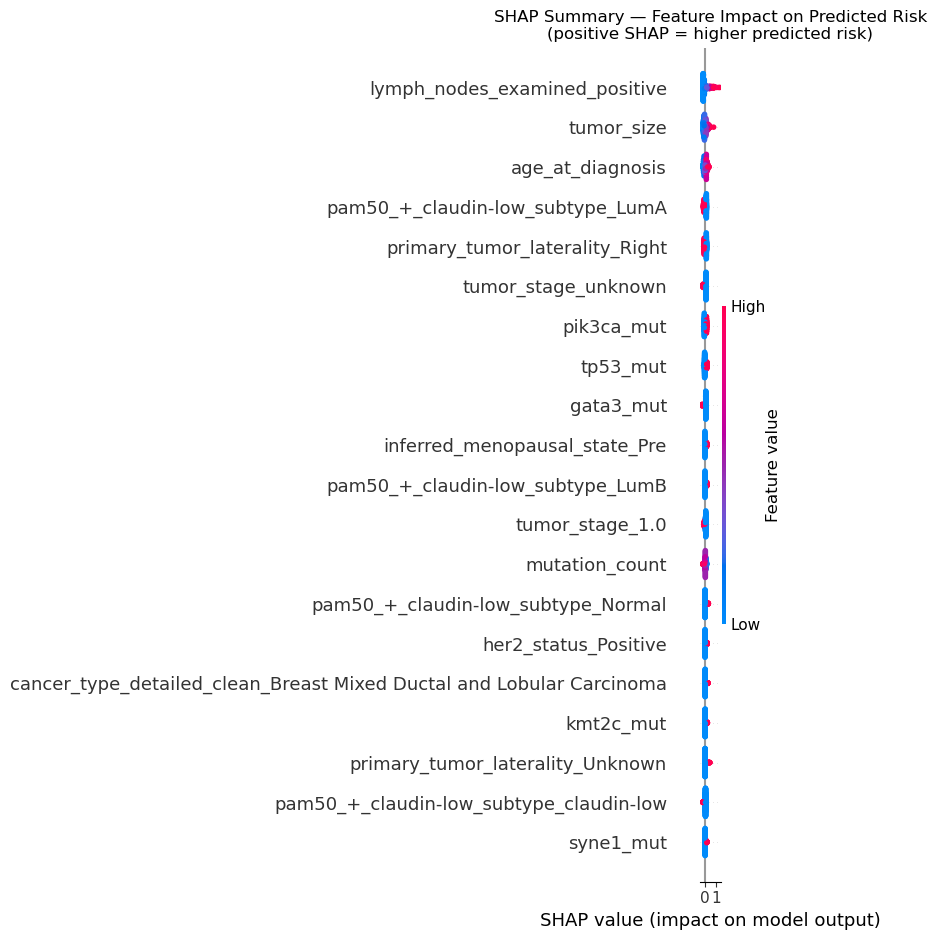

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1429561069.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


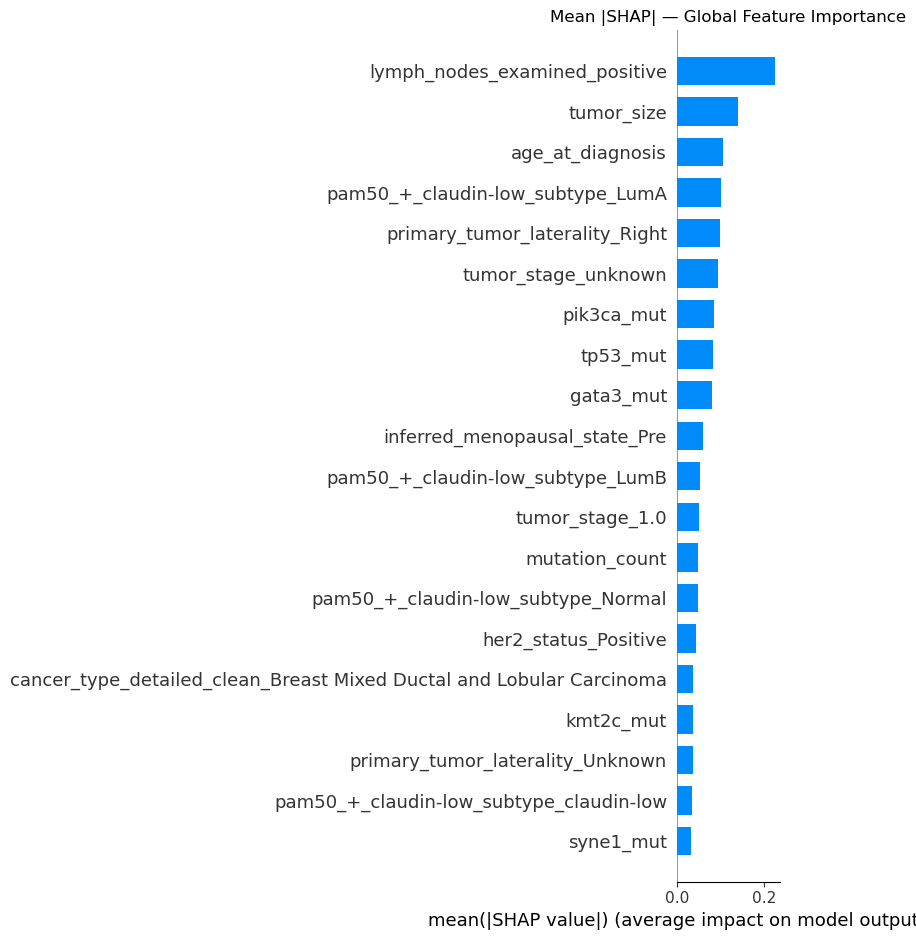


Top 10 most important features:
                         feature  importance     type
   lymph_nodes_examined_positive    0.225422 clinical
                      tumor_size    0.141166 clinical
                age_at_diagnosis    0.106365 clinical
pam50_+_claudin-low_subtype_LumA    0.100339 clinical
  primary_tumor_laterality_Right    0.099345 clinical
             tumor_stage_unknown    0.094229 clinical
                      pik3ca_mut    0.084554 mutation
                        tp53_mut    0.084231 mutation
                       gata3_mut    0.080397 mutation
   inferred_menopausal_state_Pre    0.060420 clinical

Total importance by modality:
type
clinical    1.319320
mutation    0.606214
Name: importance, dtype: float64


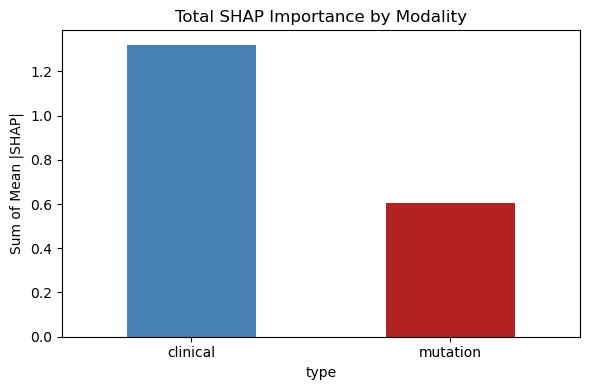

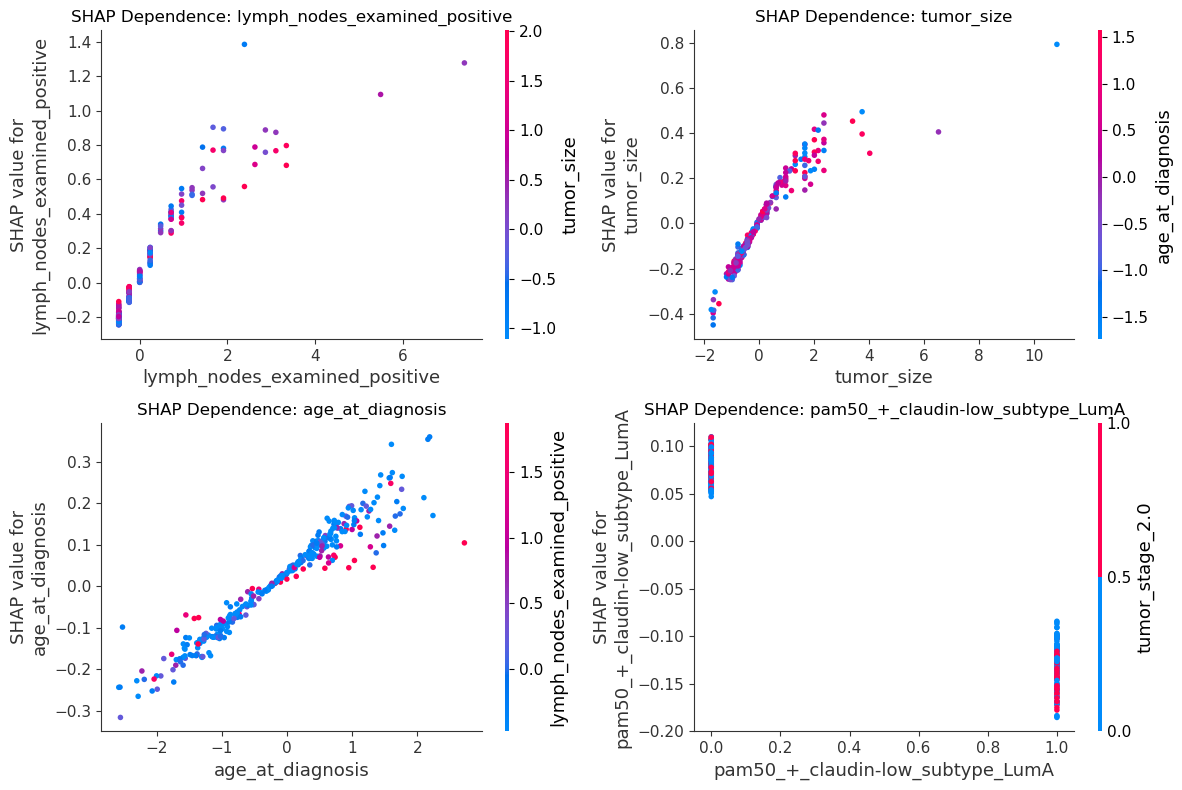


Computing SHAP values for expression features...

Top 20 most important expression features:
  gene  importance
stat5a    0.014680
 aurka    0.012651
 vegfa    0.012629
 apaf1    0.012450
  bcl2    0.012137
   bmf    0.011534
 smad6    0.011485
cdkn2c    0.011268
   fn1    0.011204
 mmp11    0.011029
stat5b    0.010742
  jag2    0.010415
  cdk2    0.010193
  hes6    0.010029
  e2f7    0.009875
 maml1    0.009677
   src    0.009653
 erbb2    0.009634
 pdgfb    0.009552
tubb4b    0.009475


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83463/1429561069.py:186: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


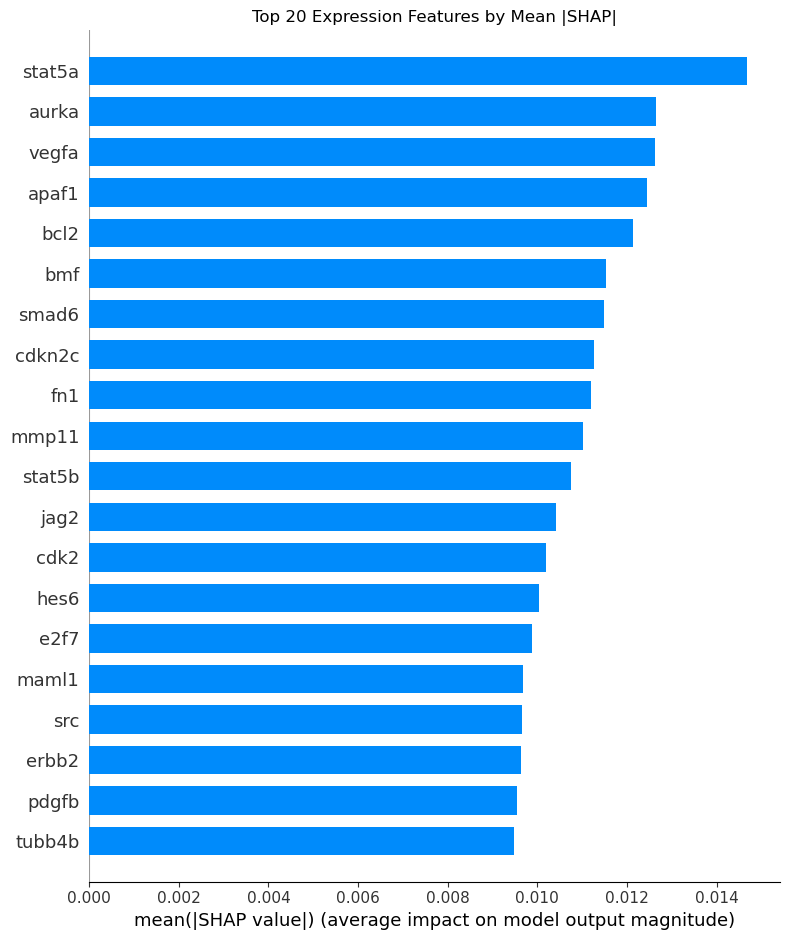


SHAP analysis complete. Files saved:
  shap_summary.png
  shap_bar.png
  shap_modality.png
  shap_dependence.png
  shap_expression_bar.png
  shap_clinical_values.npy
  shap_expression_values.npy
  feature_importance.csv
  gene_importance.csv


In [114]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

set_seed(42)
model_surv_ae.eval()

# ── Wrapper: fix expression input, vary clinical+mutation ─────────
# SHAP varies one modality at a time — we fix expression to the
# mean so SHAP values reflect clinical/mutation feature importance

class ClinicalMutWrapper(nn.Module):
    """Wraps model to accept only clinical+mutation input.
    Expression is fixed to training mean — isolates clinical signal."""
    def __init__(self, model, fixed_expr):
        super().__init__()
        self.model      = model
        self.fixed_expr = fixed_expr

    def forward(self, x_clin):
        expr = self.fixed_expr.expand(x_clin.shape[0], -1)
        return self.model(x_clin, expr).unsqueeze(1)


mean_expr    = expr_train_tensor.mean(dim=0, keepdim=True)
clin_wrapper = ClinicalMutWrapper(model_surv_ae, mean_expr)
clin_wrapper.eval()

# ── Background dataset ────────────────────────────────────────────
# Use k-means summary of training data (faster than full dataset)
# 100 background samples is standard for DeepExplainer
background = X_train_tensor[:100]

# ── SHAP explainer ────────────────────────────────────────────────
print("Building SHAP explainer...")
explainer = shap.DeepExplainer(clin_wrapper, background)

# Explain validation set (use all val patients for stable estimates)
print("Computing SHAP values for validation set...")
shap_values = explainer.shap_values(X_val_tensor)

# shap_values shape: (n_patients, n_features, 1) — squeeze last dim
if isinstance(shap_values, list):
    shap_vals = shap_values[0]
else:
    shap_vals = shap_values

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")
print(f"Features:          {len(full_feature_names)}")


# ── Plot 1: Summary plot (beeswarm) ───────────────────────────────
# Shows distribution of SHAP values for each feature
# Red = high feature value, Blue = low feature value
plt.figure()
shap.summary_plot(
    shap_vals,
    X_val_tensor.numpy(),
    feature_names=full_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Feature Impact on Predicted Risk\n"
          "(positive SHAP = higher predicted risk)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 2: Bar plot — mean absolute SHAP (feature importance) ────
plt.figure()
shap.summary_plot(
    shap_vals,
    X_val_tensor.numpy(),
    feature_names=full_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Mean |SHAP| — Global Feature Importance")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 3: Clinical vs mutation importance breakdown ─────────────
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    "feature":    full_feature_names,
    "importance": mean_abs_shap,
    "type":       ["clinical"] * len(clin_feature_names) +
                  ["mutation"] * len(mutation_feature_names)
}).sort_values("importance", ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

# Group importance by modality
modality_importance = importance_df.groupby("type")["importance"].sum()
print(f"\nTotal importance by modality:")
print(modality_importance)

fig, ax = plt.subplots(figsize=(6, 4))
modality_importance.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_title("Total SHAP Importance by Modality")
ax.set_ylabel("Sum of Mean |SHAP|")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("shap_modality.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 4: Top feature dependence plots ─────────────────────────
# Shows how SHAP value changes with feature value for top features
top_features = importance_df.head(4)["feature"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.flatten(), top_features):
    feat_idx = full_feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_vals,
        X_val_tensor.numpy(),
        feature_names=full_feature_names,
        ax=ax,
        show=False
    )
    ax.set_title(f"SHAP Dependence: {feat}")

plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 5: Expression modality importance ────────────────────────
# Separate SHAP analysis on expression latent dimensions
# Shows which latent dimensions drive predictions

class ExprOnlyWrapper(nn.Module):
    """Wraps model to accept only expression input.
    Clinical fixed to training mean — isolates expression signal."""
    def __init__(self, model, fixed_clin):
        super().__init__()
        self.model      = model
        self.fixed_clin = fixed_clin

    def forward(self, x_expr):
        clin = self.fixed_clin.expand(x_expr.shape[0], -1)
        return self.model(clin, x_expr).unsqueeze(1)


mean_clin     = X_train_tensor.mean(dim=0, keepdim=True)
expr_wrapper  = ExprOnlyWrapper(model_surv_ae, mean_clin)
expr_wrapper.eval()

print("\nComputing SHAP values for expression features...")
expr_background  = expr_train_tensor[:100]
expr_explainer   = shap.DeepExplainer(expr_wrapper, expr_background)
expr_shap_values = expr_explainer.shap_values(expr_val_tensor)

if isinstance(expr_shap_values, list):
    expr_shap_vals = expr_shap_values[0]
else:
    expr_shap_vals = expr_shap_values

if expr_shap_vals.ndim == 3:
    expr_shap_vals = expr_shap_vals[:, :, 0]

# Get gene names from expression data
gene_names = list(expression_data.columns)

# Top expression features by mean |SHAP|
expr_importance = pd.DataFrame({
    "gene":       gene_names,
    "importance": np.abs(expr_shap_vals).mean(axis=0)
}).sort_values("importance", ascending=False)

print("\nTop 20 most important expression features:")
print(expr_importance.head(20).to_string(index=False))

# Plot top 20 expression features
plt.figure(figsize=(8, 6))
shap.summary_plot(
    expr_shap_vals,
    expr_val_tensor.numpy(),
    feature_names=gene_names,
    max_display=20,
    plot_type="bar",
    show=False
)
plt.title("Top 20 Expression Features by Mean |SHAP|")
plt.tight_layout()
plt.savefig("shap_expression_bar.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Save SHAP values for further analysis ─────────────────────────
np.save("shap_clinical_values.npy",   shap_vals)
np.save("shap_expression_values.npy", expr_shap_vals)

importance_df.to_csv("feature_importance.csv", index=False)
expr_importance.to_csv("gene_importance.csv",  index=False)

print("\nSHAP analysis complete. Files saved:")
print("  shap_summary.png")
print("  shap_bar.png")
print("  shap_modality.png")
print("  shap_dependence.png")
print("  shap_expression_bar.png")
print("  shap_clinical_values.npy")
print("  shap_expression_values.npy")
print("  feature_importance.csv")
print("  gene_importance.csv")

# Combined Model Evaluation Figures

## Kaplan Meier Curves

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

# Split into risk tertiles
tertiles = np.percentile(val_risk, [33, 66])
risk_group = np.digitize(val_risk, tertiles)  # 0=low, 1=mid, 2=high

# KM curves
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for group, label, color in zip(
    [0, 1, 2],
    ["Low Risk", "Mid Risk", "High Risk"],
    ["steelblue", "orange", "firebrick"]
):
    mask = risk_group == group
    kmf.fit(time_val[mask], event_val[mask], label=f"{label} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier Curves by Predicted Risk Tertile (Validation Set)")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()